# Political Answer Clarity Classification

The goal of this work is to predict the clarity of politician responses to journalist questions into three categories: *Clear Reply*, *Ambivalent*, and *Clear Non-Reply*.

**Dataset:** [ailsntua/QEvasion](https://huggingface.co/datasets/ailsntua/QEvasion) (Hugging Face)    
**Models:** TF-IDF + Logistic Regression, Word2Vec + Logistic Regression  
**Evaluation:** Accuracy, Precision, Recall, F1-Score

## Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from itertools import product
from collections import Counter
import scipy.sparse

!pip install gdown
!pip install gensim
import gensim.downloader

from datasets import load_dataset
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

SEED = 42

## Load Dataset

In [2]:
# Load the dataset HuggingFace
dataset = load_dataset("ailsntua/QEvasion")

In [3]:
print(f"Type of variables of the dataset: {type(dataset)}")
dataset

Type of variables of the dataset: <class 'datasets.dataset_dict.DatasetDict'>


DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 3448
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 308
    })
})

## Exploratory Data Analysis (EDA)

### Sample Inspection  

In [4]:
# Inspect the first train sample
sample = dataset["train"][0]
sample

{'title': "The President's News Conference in Hanoi, Vietnam",
 'date': 'September 10, 2023',
 'president': 'Joseph R. Biden',
 'url': 'https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-hanoi-vietnam-0',
 'question_order': 1,
 'interview_question': 'Q. Of the Biden administration. And accused the United States of containing China while pushing for diplomatic talks.How would you respond to that? And do you think President Xi is being sincere about getting the relationship back on track as he bans Apple in China?',
 'interview_answer': "Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now talking about making sure that no Chineseno one in the Chinese Government can use a Western cell phone. Those kinds of things.And so, reall

In [5]:
print(f"Type of samples of the dataset: {type(sample)}")
print(f"Keys of sample-dicts of the dataset: {sample.keys()}")

Type of samples of the dataset: <class 'dict'>
Keys of sample-dicts of the dataset: dict_keys(['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'])


In [6]:
title = sample['title']
president = sample['president']
print(f"Our first training sample has the title '{title}' and concerns president '{president}'.")

Our first training sample has the title 'The President's News Conference in Hanoi, Vietnam' and concerns president 'Joseph R. Biden'.


### Dataset Overview

In [7]:
# Convert to pandas DataFrames
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

# Display first 3 samples of train set
train_df.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,85,None,None,None,False,False,False,0,Clear Reply,Explicit
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,85,None,None,None,False,False,False,1,Ambivalent,General
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,85,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer


In [8]:
# Display only question, answer and label of first 3 samples of train set
for i in range(3):
  print(f"\nSample {i+1}:")
  print(dataset["train"]["question"][i])
  print(dataset["train"]["interview_answer"][i])
  print(dataset["train"]["clarity_label"][i])


Sample 1:
How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks?
Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now talking about making sure that no Chineseno one in the Chinese Government can use a Western cell phone. Those kinds of things.And so, really, what this trip was aboutit was less about containing China. I don't want to contain China. I just want to make sure that we have a relationship with China that is on the up and up, squared away, everybody knows what it's all about. And one of the ways you do that is, you make sure that we are talking about the same things.And I think that one of the things we've doneI've tried to do, and I've talked with a number of my staff ab

In [9]:
# Display first 3 samples of test set
test_df.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,5,"Q. What about the redline, sir?","Well, the world has made it clear that these t...",None,None,Inquiring about the status or information reg...,None,Dodging,General,Dodging,False,False,True,0,Ambivalent,
1,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,2,Q. Will you invite them to the White House to ...,I think that anytime and anyplace that they ar...,None,None,Will you invite them to the White House to neg...,None,Deflection,General,General,False,False,False,1,Ambivalent,
2,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Harsh. Mr. President, Japan has dropped the...",I think that the purpose of the U.N. Security ...,None,None,Why was it necessary for Japan to drop the thr...,None,Explicit,Implicit,Implicit,False,False,False,2,Ambivalent,


In [10]:
# Display only question, answer and label of first 3 samples of test set
for i in range(3):
  print(f"\nSample {i+1}:")
  print(dataset["test"]["question"][i])
  print(dataset["test"]["interview_answer"][i])
  print(dataset["test"]["clarity_label"][i])


Sample 1:
 Inquiring about the status or information regarding the redline.
Well, the world has made it clear that these tests caused us to come together and work in the United Nations to send a clear message to the North Korean regime. We're bound up together with a common strategy to solve this issue peacefully through diplomatic means.Kevin [Kevin Corke, NBC News].
Ambivalent

Sample 2:
Will you invite them to the White House to negotiate on the jobs bill?
I think that anytime and anyplace that they are serious about working on putting people back to work, we'll be prepared to work with them. But we're not going to create a lot of theater that then results in them engaging in the usual political talking points, but don't result in action.People want action. And I'm prepared to work with them. But again, the last time I was here at a press conference I said--I asked you guys to show us the Republican jobs plan that independent economists would indicate would actually put people back

In [11]:
# Check train/test shapes
print(f"Shapes: Train: {train_df.shape} | Test: {test_df.shape}")

Shapes: Train: (3448, 20) | Test: (308, 20)


In [12]:
# Dtypes, nulls/missing values
print("Train")
display(pd.concat([train_df.dtypes.rename("dtype"), train_df.isnull().sum().rename("nulls")], axis=1))

print("\nTest")
display(pd.concat([test_df.dtypes.rename("dtype"), test_df.isnull().sum().rename("nulls")], axis=1))

Train


,dtype,nulls
title,object,0
date,object,0
president,object,0
url,object,0
question_order,int64,0
interview_question,object,0
interview_answer,object,0
gpt3.5_summary,object,0
gpt3.5_prediction,object,0
question,object,0



Test


,dtype,nulls
title,object,308
date,object,308
president,object,308
url,object,0
question_order,int64,0
interview_question,object,0
interview_answer,object,0
gpt3.5_summary,object,308
gpt3.5_prediction,object,308
question,object,0


In [13]:
# Duplicates check on raw dataset (before preprocessing and input construction)
print(f"Duplicates: Train: {train_df.duplicated().sum()} | Test: {test_df.duplicated().sum()}")

Duplicates: Train: 0 | Test: 0


### Class Distributions

In [14]:
# Class distribution of clarity_label (train set)
label_counts = train_df["clarity_label"].value_counts()
display(pd.DataFrame({
    "count": label_counts,
    "%": (label_counts / len(train_df) * 100).round(2)
}))

,count,%
clarity_label,,
Ambivalent,2040,59.16
Clear Reply,1052,30.51
Clear Non-Reply,356,10.32


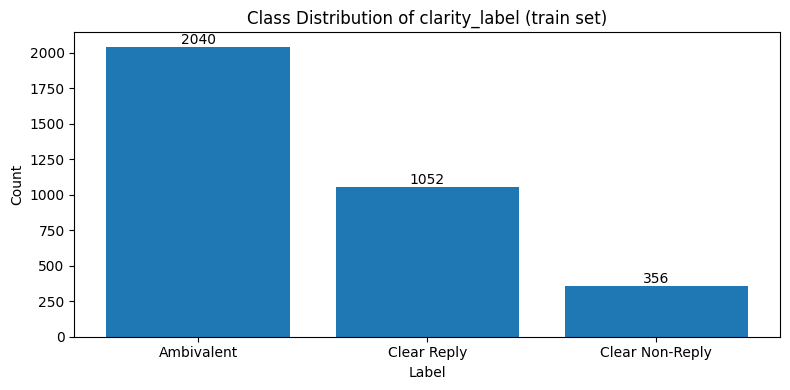

In [15]:
# Class distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(label_counts.index, label_counts.values)
ax.set_title("Class Distribution of clarity_label (train set)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(label_counts.values):
  ax.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Class imbalance detected:** Ambivalent dominates with 59%, Clear Reply accounts for 30%, and Clear Non-Reply is rare, represented by 10%. This may affect model performance.

In [16]:
# Train vs test class distribution comparison
train_counts = train_df["clarity_label"].value_counts()
test_counts = test_df["clarity_label"].value_counts()

display(pd.DataFrame({
    "train_count": train_counts,
    "train_%": (train_counts / len(train_df) * 100).round(2),
    "test_count": test_counts,
    "test_%": (test_counts / len(test_df) * 100).round(2)
}))

,train_count,train_%,test_count,test_%
clarity_label,,,,
Ambivalent,2040,59.16,206,66.88
Clear Reply,1052,30.51,79,25.65
Clear Non-Reply,356,10.32,23,7.47


#### Inspect some samples per class

In [17]:
# 'Ambivalent' samples
ambivalent_train_samples = train_df[train_df['clarity_label'] == 'Ambivalent']
ambivalent_train_samples.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,85,None,None,None,False,False,False,1,Ambivalent,General
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,85,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer
3,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Are you worried about the meeting between Pre...,85,None,None,None,False,False,False,3,Ambivalent,Dodging


In [18]:
# 'Clear Reply' samples
clear_reply_train_samples = train_df[train_df['clarity_label'] == 'Clear Reply']
clear_reply_train_samples.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,85,None,None,None,False,False,False,0,Clear Reply,Explicit
4,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,3,"Q. I can imagine. It is evening, I'd like to r...","Well, I hope I get to see Mr. Xi sooner than l...",The question consists of 3 parts:\n1. Is the P...,Question part: 1. Is the President's engagemen...,Is the President's engagement with Asian coun...,85,None,None,None,False,False,False,4,Clear Reply,Explicit
8,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,5,"Q. Well, let me ask you about—you've spent lot...",It's not a wedge issue of the Global South. It...,The question consists of 2 parts:\n\n1. Concer...,Question part 1: Concerns about the lack of co...,Concerns about the lack of communication betw...,85,None,None,None,False,False,True,8,Clear Reply,Explicit


In [19]:
# 'Clear Non-Reply' samples
clear_non_reply_train_samples = train_df[train_df['clarity_label'] == 'Clear Non-Reply']
clear_non_reply_train_samples.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
10,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,6,Q. What did you talk about with him?,We talked about what we talked about at the co...,The question consists of 1 part:\n\nPart 1: Wh...,Question part: 1 - What did you talk about wit...,What did you talk about with him?,85,None,None,None,True,False,False,10,Clear Non-Reply,Declining to answer
25,The President's News Conference With President...,"July 13, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,8,"Q. Thank you, Mr. President. We've seen more d...","Well, first of all, they already interfered in...",The question consists of 2 parts:\n\n1. Does t...,Question part: 1 - Does this raise any new con...,Does the firing of the general and the rebell...,85,None,None,None,False,False,False,25,Clear Non-Reply,Claims ignorance
31,The President's News Conference With Prime Min...,"June 22, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Thank you, Mr. President. I have a question...",The answer to your first question is: No. You ...,The question consists of 2 parts:\n\n1. Did th...,Question part: 1. Did the comments about Presi...,What is the message to those who say the admin...,85,None,None,None,False,False,False,31,Clear Non-Reply,Clarification


### Text Length Analysis

In [20]:
# Text length statistics (train set)
display(train_df["question"].str.split().str.len().describe().round(2).to_frame())
display(train_df["interview_answer"].str.split().str.len().describe().round(2).to_frame())

,question
count,3448.00
mean,14.46
std,8.83
min,1.00
25%,8.00
50%,12.00
75%,19.00
max,80.00


,interview_answer
count,3448.00
mean,293.57
std,301.54
min,1.00
25%,56.00
50%,207.00
75%,440.00
max,2117.00


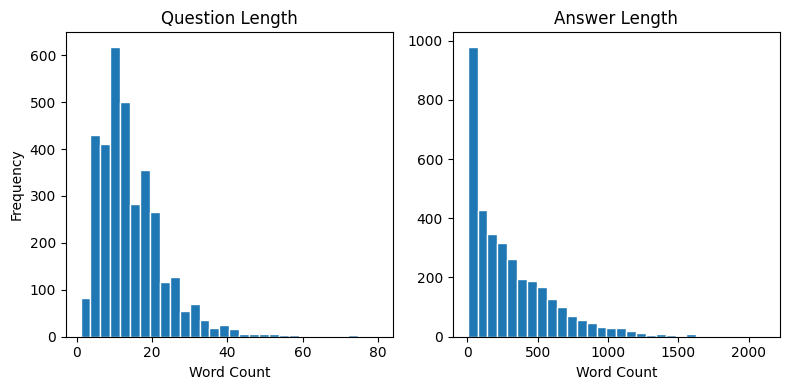

In [21]:
# Word count distribution
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].hist(train_df["question"].str.split().str.len(), bins=30, edgecolor="white")
axes[0].set_title("Question Length")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(train_df["interview_answer"].str.split().str.len(), bins=30, edgecolor="white")
axes[1].set_title("Answer Length")
axes[1].set_xlabel("Word Count")

plt.tight_layout()
plt.savefig("text_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Questions** are short and consistent (5–25 words), roughly normal distribution. **Answers** are heavily right-skewed, most are short but some exceed 1000 words.

In [22]:
# Answer length per class for: do longer answers correlate with clarity? (train set)
ans_len = train_df["interview_answer"].str.split().str.len()
display(ans_len.groupby(train_df["clarity_label"]).describe().round(2))

,count,mean,std,min,25%,50%,75%,max
clarity_label,,,,,,,,
Ambivalent,2040.0,331.86,319.53,1.0,82.75,243.5,491.75,2117.0
Clear Non-Reply,356.0,137.81,217.39,1.0,12.00,39.5,179.25,1407.0
Clear Reply,1052.0,272.04,269.54,1.0,57.75,194.0,415.25,1592.0


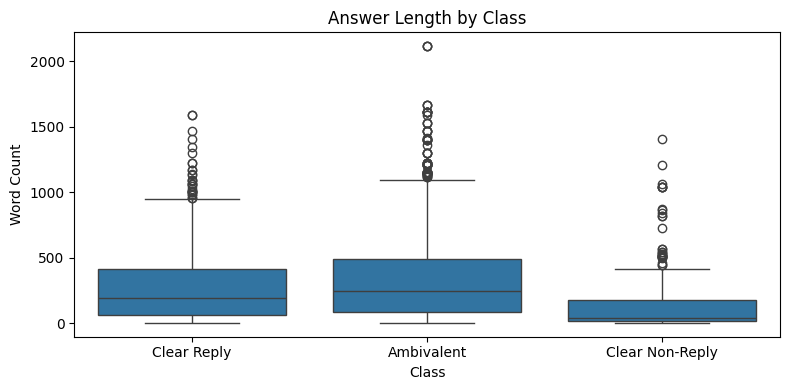

In [23]:
# Answer length per class boxplot
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=train_df["clarity_label"], y=ans_len, ax=ax)
ax.set_title("Answer Length by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Word Count")
plt.tight_layout()
plt.savefig("answer_length_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

**Ambivalent** answers tend to be longest, while **Clear Non-Reply** answers are the shortest, suggesting politicians who avoid questions do it briefly.

,count,mean,std,min,25%,50%,75%,max
clarity_label,,,,,,,,
Ambivalent,2040.0,15.30,9.13,1.0,9.0,14.0,20.0,80.0
Clear Non-Reply,356.0,12.63,7.85,1.0,7.0,11.0,16.0,55.0
Clear Reply,1052.0,13.45,8.36,1.0,8.0,12.0,17.0,62.0


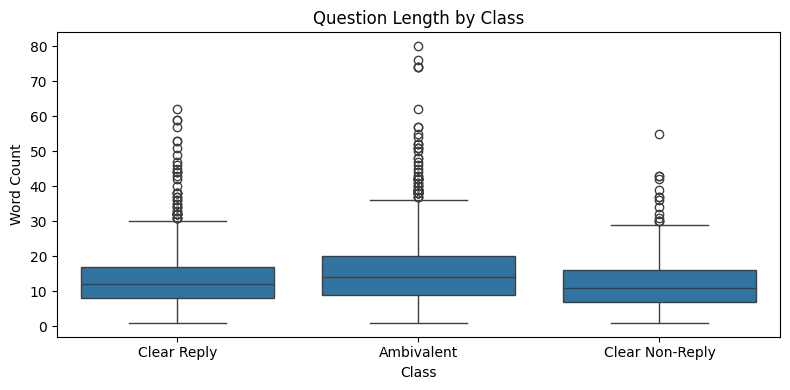

In [24]:
# Question length per class
q_len = train_df["question"].str.split().str.len()
display(q_len.groupby(train_df["clarity_label"]).describe().round(2))

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=train_df["clarity_label"], y=q_len, ax=ax)
ax.set_title("Question Length by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Word Count")
plt.tight_layout()
plt.savefig("question_length_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

**Questions** are short and nearly identical in length across all three classes (mean 12–15 words), confirming that question length carries no discriminative signal for clarity classification.

### President Distribution

In [25]:
# Inspect president column
president_column = train_df["president"]
display(president_column.describe().to_frame())

,president
count,3448
unique,4
top,Donald J. Trump
freq,1325


In [26]:
# Unique values
print(president_column.unique())

['Joseph R. Biden' 'Donald J. Trump' 'Barack Obama' 'George W. Bush']


In [27]:
# Column distribution
pres_counts = president_column.value_counts()
display(pres_counts.to_frame())

,count
president,
Donald J. Trump,1325
Barack Obama,1010
George W. Bush,714
Joseph R. Biden,399


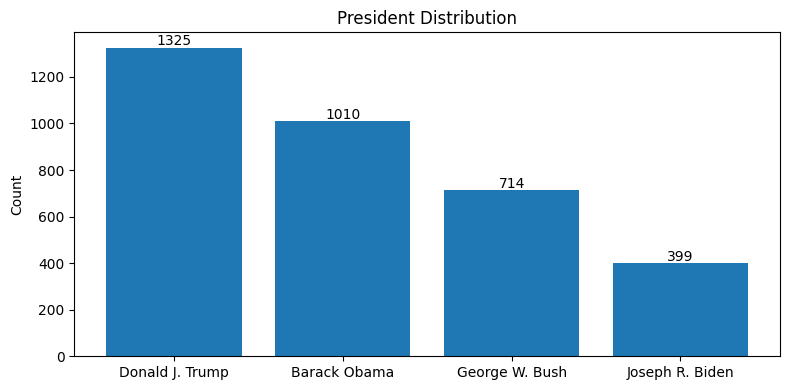

In [28]:
# President distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(pres_counts.index, pres_counts.values)
ax.set_title("President Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(pres_counts.values):
  ax.text(i, v + 10, str(v), ha="center")
plt.tight_layout()
plt.savefig("president_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Trump** dominates the dataset (38%), which may introduce bias toward his speaking style.

In [29]:
# President vs clarity label
pres_clarity = train_df.pivot_table(index="president", columns="clarity_label", aggfunc="size")
display(pres_clarity)

clarity_label,Ambivalent,Clear Non-Reply,Clear Reply
president,,,
Barack Obama,688,96,226
Donald J. Trump,737,156,432
George W. Bush,407,62,245
Joseph R. Biden,208,42,149


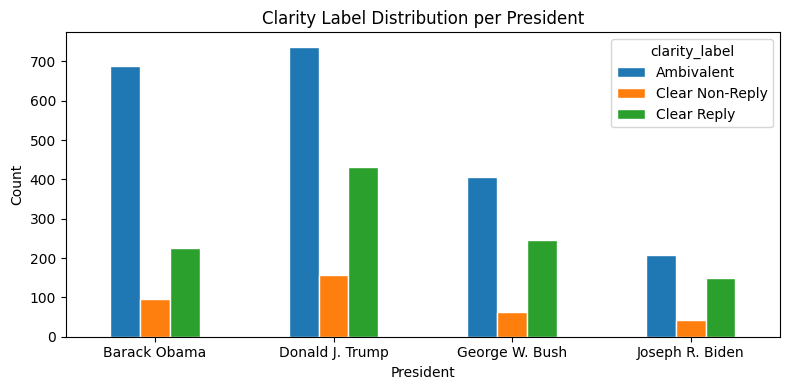

In [30]:
# President vs clarity label plot
pres_clarity.plot(kind="bar", figsize=(8, 4), edgecolor="white")
plt.title("Clarity Label Distribution per President")
plt.xlabel("President")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution_per_president.png", dpi=150, bbox_inches="tight")
plt.show()

All presidents follow the same pattern: **Ambivalent** dominates across the board, confirming the class imbalance is not president-specific. In all cases, **Clear Reply** ranks second and **Clear Non-Reply** is the least frequent. Same imbalance pattern across all presidents like the one detected previously. Since all presidents exhibit the same class distribution pattern, potentially adding `president` as a feataure is unlikely to improve classification performance (likely because president identity is not a reliable signal for clarity classification, and this probably the reason why all values are None in the test set for president column).

### Word Frequency Analysis

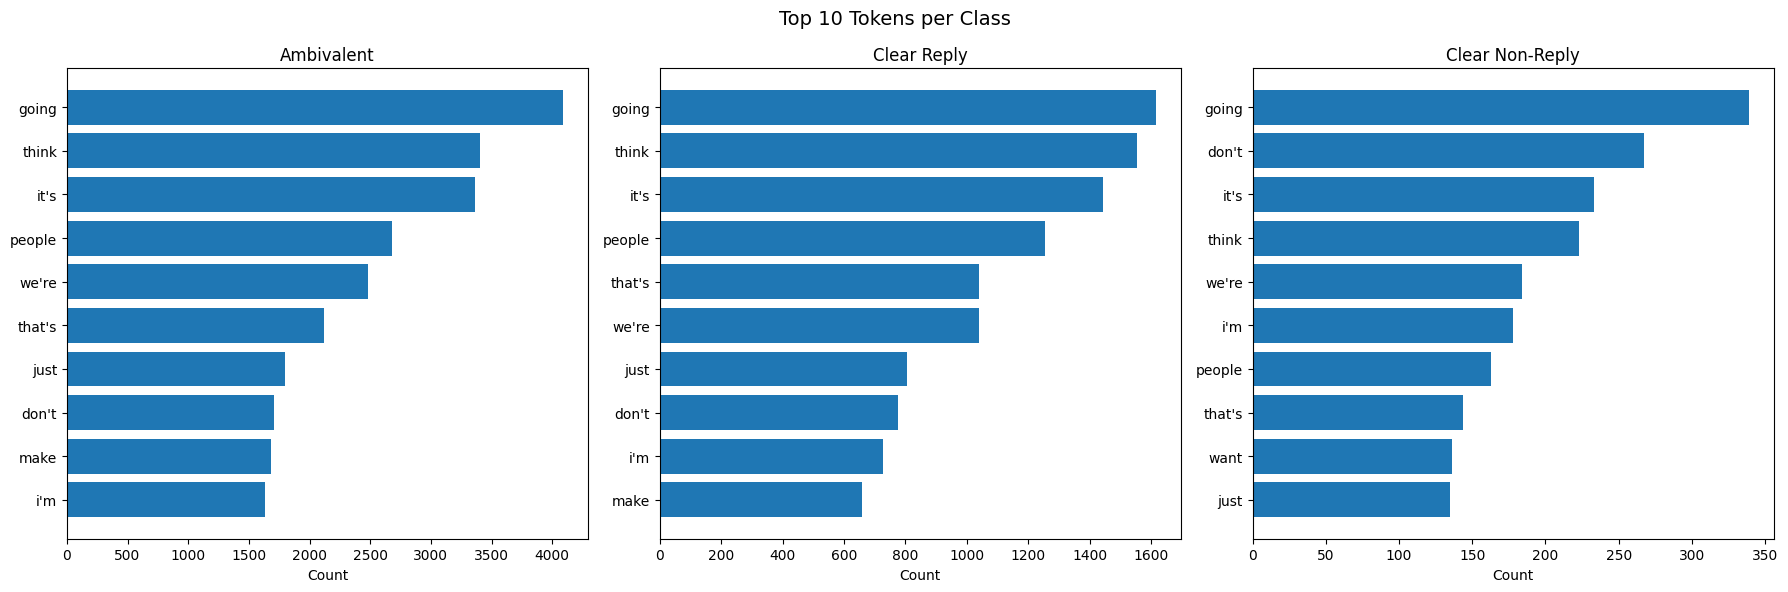

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
labels = ["Ambivalent", "Clear Reply", "Clear Non-Reply"]

for ax, label in zip(axes, labels):
  # Get all words for this class, excluding stopwords
  texts = " ".join(train_df[train_df["clarity_label"] == label]["interview_answer"].values).split()
  filtered = [w.lower() for w in texts if w.lower() not in ENGLISH_STOP_WORDS]
  top_words = Counter(filtered).most_common(10)
  words, counts = zip(*top_words)

  ax.barh(words[::-1], counts[::-1])
  ax.set_title(label)
  ax.set_xlabel("Count")

plt.suptitle("Top 10 Tokens per Class", fontsize=14)
plt.tight_layout()
plt.savefig("top_tokens_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

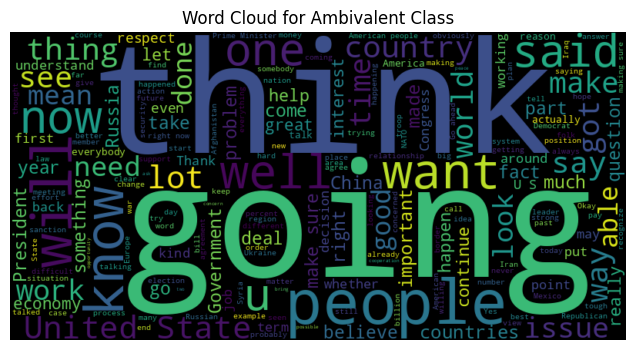

In [32]:
# WordCloud for Ambivalent answers
text = " ".join(train_df[train_df["clarity_label"] == "Ambivalent"]["interview_answer"])
wc = WordCloud(width=800, height=400).generate(text)
plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation="bilinear")
plt.title("Word Cloud for Ambivalent Class")
plt.axis("off")
plt.savefig("wordcloud_ambivalent.png", dpi=150, bbox_inches="tight")
plt.show()

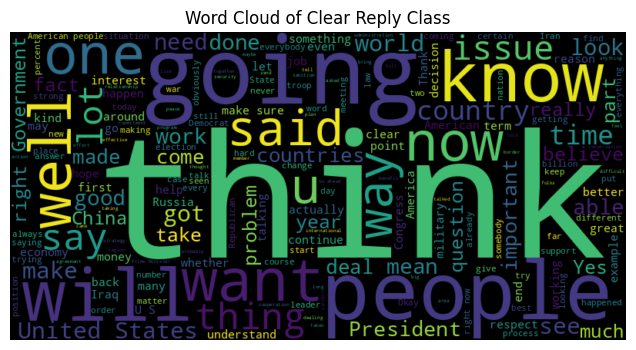

In [33]:
# WordCloud for Clear Reply answers
text = " ".join(train_df[train_df["clarity_label"] == "Clear Reply"]["interview_answer"])
wc = WordCloud(width=800, height=400).generate(text)
plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation="bilinear")
plt.title("Word Cloud of Clear Reply Class")
plt.axis("off")
plt.savefig("wordcloud_clear_reply.png", dpi=150, bbox_inches="tight")
plt.show()

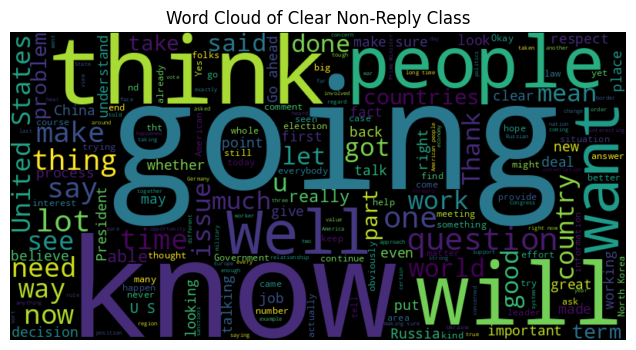

In [34]:
# WordCloud for Clear Non-Reply answers
text = " ".join(train_df[train_df["clarity_label"] == "Clear Non-Reply"]["interview_answer"])
wc = WordCloud(width=800, height=400).generate(text)
plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation="bilinear")
plt.title("Word Cloud of Clear Non-Reply Class")
plt.axis("off")
plt.savefig("wordcloud_clear_nonreply.png", dpi=150, bbox_inches="tight")
plt.show()

## Text Preprocessing

In [35]:
# Simpple preprocessing function to clean the text
def preprocess(text: str) -> str:
  """
  Clean and normalize raw text.

  Args: text as raw input string
  Returns: cleaned lowercase string
  """
  # text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)  # "theI" -> "the I" -> too aggressive, breaks normal words
  text = re.sub(r"^q\.\s*", "", text, flags=re.IGNORECASE)  # remove "Q." at start
  text = re.sub(r"\[.*?\]", " ", text)  # remove brackets, e.g., [laughter], [applause] etc
  text = text.lower() # lowercase
  # text = text.replace("’", "'").replace("'", "")  # e.g., "don't" -> "dont"
  text = re.sub(r"[^a-z0-9\s?]", " ", text) # remove anything that is not letter, number or space, keep '?'
  text = re.sub(r"\s+", " ", text).strip() # unify multiple spaces into one
  return text

In [36]:
# Test preprocess function
tests = [
    "Q. How would you respond to that? theI am sincere.",
    "Well, look [Laughter] I'm thinking China has difficulties.",
    "THE PrEsidenT says:'NO ComMent'?  Multiple   spaces!",
]

for t in tests:
  print(f"In: {t}")
  print(f"Out: {preprocess(t)}\n")

In: Q. How would you respond to that? theI am sincere.
Out: how would you respond to that? thei am sincere

In: Well, look [Laughter] I'm thinking China has difficulties.
Out: well look i m thinking china has difficulties

In: THE PrEsidenT says:'NO ComMent'?  Multiple   spaces!
Out: the president says no comment ? multiple spaces



In [37]:
# First train sample before preprocessing
print(train_df["question"].iloc[0], "\n")
print(train_df["interview_answer"].iloc[0])

How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks? 

Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now talking about making sure that no Chineseno one in the Chinese Government can use a Western cell phone. Those kinds of things.And so, really, what this trip was aboutit was less about containing China. I don't want to contain China. I just want to make sure that we have a relationship with China that is on the up and up, squared away, everybody knows what it's all about. And one of the ways you do that is, you make sure that we are talking about the same things.And I think that one of the things we've doneI've tried to do, and I've talked with a number of my staff about this 

In [38]:
# Apply preprocessing to question and interview_answer
for df in [train_df, test_df]:
  df["question"] = df["question"].apply(preprocess)
  df["interview_answer"] = df["interview_answer"].apply(preprocess)

In [39]:
# Verify preprocessing on first train samaple
print(train_df["question"].iloc[0], "\n")
print(train_df["interview_answer"].iloc[0])

how would you respond to the accusation that the united states is containing china while pushing for diplomatic talks? 

well look first of all thei am sincere about getting the relationship right and one of the things that is going on now is china is beginning to change some of the rules of the game in terms of trade and other issues and so one of the things we talked about for example is that they re now talking about making sure that no chineseno one in the chinese government can use a western cell phone those kinds of things and so really what this trip was aboutit was less about containing china i don t want to contain china i just want to make sure that we have a relationship with china that is on the up and up squared away everybody knows what it s all about and one of the ways you do that is you make sure that we are talking about the same things and i think that one of the things we ve donei ve tried to do and i ve talked with a number of my staff about this for the last i gue

## Input Construction

In [40]:
# Combine question and answer into a single input by using a separator token
train_df["input"] = train_df["question"] + " [SEP] " + train_df["interview_answer"]
test_df["input"] = test_df["question"]  + " [SEP] " + test_df["interview_answer"]

In [41]:
# Inspect the first processed train input sample (notice [SEP] between question and answer)
print(train_df["input"].iloc[0])

how would you respond to the accusation that the united states is containing china while pushing for diplomatic talks? [SEP] well look first of all thei am sincere about getting the relationship right and one of the things that is going on now is china is beginning to change some of the rules of the game in terms of trade and other issues and so one of the things we talked about for example is that they re now talking about making sure that no chineseno one in the chinese government can use a western cell phone those kinds of things and so really what this trip was aboutit was less about containing china i don t want to contain china i just want to make sure that we have a relationship with china that is on the up and up squared away everybody knows what it s all about and one of the ways you do that is you make sure that we are talking about the same things and i think that one of the things we ve donei ve tried to do and i ve talked with a number of my staff about this for the last i

## Create Splits

In [42]:
# Stratified split of train_df
train_set, val_set = train_test_split(train_df, test_size=0.15, random_state=SEED, stratify=train_df["clarity_label"]) # startify for keeping class proportions equal in both splits

In [43]:
# Confirm stratisfaction preserved original class proportions  in both splits
print(f"train_set: {train_set.shape} | val_set: {val_set.shape}")
print(f"\nClass distribution in train_set: {(train_set["clarity_label"].value_counts(normalize=True)*100).round(2)}")
print(f"\nClass distribution in val_set: {(val_set["clarity_label"].value_counts(normalize=True)*100).round(2)}")

train_set: (2930, 21) | val_set: (518, 21)

Class distribution in train_set: clarity_label
Ambivalent         59.18
Clear Reply        30.51
Clear Non-Reply    10.31
Name: proportion, dtype: float64

Class distribution in val_set: clarity_label
Ambivalent         59.07
Clear Reply        30.50
Clear Non-Reply    10.42
Name: proportion, dtype: float64


In [44]:
# Features and labels
X_train = train_set["input"]
y_train = train_set["clarity_label"]
X_val = val_set["input"]
y_val = val_set["clarity_label"]

# Original test set remains untouched
X_test = test_df["input"]
y_test = test_df["clarity_label"]

## TF-IDF + Logistic Regression

### TF-IDF Representation   

We start with the default `TfidfVectorizer` settings. Hyperparameters such as `max_features` and others will be tuned later.

In [45]:
# TF-IDF vectorization
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

In [46]:
print(f"Before TF-IDF vectorization: Train: {X_train.shape} | Val: {X_val.shape} | Type: {type(X_train)}")
print(f"After TF-IDF vectorization: Train: {X_train_tfidf.shape} | Val: {X_val_tfidf.shape} | Type: {type(X_train_tfidf)}")

Before TF-IDF vectorization: Train: (2930,) | Val: (518,) | Type: <class 'pandas.core.series.Series'>
After TF-IDF vectorization: Train: (2930, 13501) | Val: (518, 13501) | Type: <class 'scipy.sparse._csr.csr_matrix'>


In [47]:
# Inspect first train sample of TF-IDF vector
feature_names = tfidf.get_feature_names_out()
sample_vector = X_train_tfidf[0].toarray()[0]

print(f"Text: {X_train.iloc[0][:100]}...")
print(f"Shape: {sample_vector.shape}")
print("Five non-zero values:\n")

count = 0
for i, score in enumerate(sample_vector):
  if score > 0:
    count += 1
    print(f"{feature_names[i]}: {score:.2f}")
    if count == 5:
      break

Text: what can you do about that? [SEP] well i really think the stock market of something i know a lot abo...
Shape: (13501,)
Five non-zero values:

about: 0.07
also: 0.05
and: 0.19
are: 0.03
at: 0.04


### LR with TF-IDF Representation   

In [48]:
# Train LR on TF-IDF
lr_tfidf_v0 = LogisticRegression(max_iter=1000, random_state=SEED)
lr_tfidf_v0.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [49]:
# Define a custom function for accuracy
def accuracy_count(y_true, y_pred, split) -> None:
  """
  Print number and percentage of correct predictions.

  Args:
    y_true: true labels
    y_pred: predicted labels
    split: whether it  is train or val split
  """
  correct = sum(1 for t, p in zip(y_true, y_pred) if t == p)
  total = len(y_true)
  print(f"{split.capitalize()} Accurracy: {correct}/{total} ({correct/total*100:.2f}%)")

In [50]:
# Evaluate on train set: sanity check for overfitting
y_pred_train_tfidf_v0 = lr_tfidf_v0.predict(X_train_tfidf)
accuracy_count(y_train, y_pred_train_tfidf_v0, "train")

# Evaluate on val set: real performance (notice the difference between train accuracy and validation accuracy)
y_pred_tfidf_v0 = lr_tfidf_v0.predict(X_val_tfidf)
accuracy_count(y_val, y_pred_tfidf_v0, "Val")

Train Accurracy: 2258/2930 (77.06%)
Val Accurracy: 329/518 (63.51%)


In [51]:
# Inspect some predictions
for i in range(5):
  print(f"Input: {val_set["input"].iloc[i][:100]}...")
  print(f"True: {val_set["clarity_label"].iloc[i]}")
  print(f"Predicted: {y_pred_tfidf_v0[i]}\n")

Input: how concerned are you about whether this might undermine pakistani efforts against the taliban and a...
True: Ambivalent
Predicted: Ambivalent

Input: what did you hope that that would accomplish? [SEP] thank you let me correct the record we briefed 2...
True: Clear Reply
Predicted: Ambivalent

Input: invitation to join a video summit with iran and other world powers [SEP] i haven t been told of it y...
True: Clear Non-Reply
Predicted: Ambivalent

Input: given the way you ran for office and the aspirations you brought into office how do you feel about t...
True: Ambivalent
Predicted: Ambivalent

Input: will you call chinese president xi when you come back to dc? [SEP] yes i will...
True: Clear Reply
Predicted: Ambivalent



                 precision    recall  f1-score   support

     Ambivalent       0.64      0.92      0.75       306
Clear Non-Reply       0.67      0.15      0.24        54
    Clear Reply       0.61      0.26      0.36       158

       accuracy                           0.64       518
      macro avg       0.64      0.44      0.45       518
   weighted avg       0.63      0.64      0.58       518



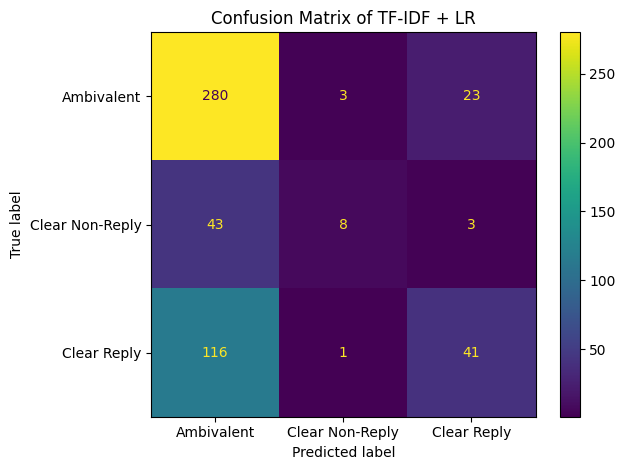

In [52]:
# Classification report with detailed metrics: accuracy, presicion, recall, f1-score
print(classification_report(y_val, y_pred_tfidf_v0))

# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_tfidf_v0)
plt.title("Confusion Matrix of TF-IDF + LR")
plt.tight_layout()
plt.savefig("confusion_matrix_v0_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
def plot_learning_curves(model, X_train, y_train, X_val, y_val, title: str) -> None:
  """
  Train model on increasing subsets of training data and plot train vs val F1.

  Args:
    model: sklearn estimator
    X_train/y_train: training data
    X_val/y_val: validation data
    title: plot title
  """
  list_f1_train = []
  list_f1_val = []
  list_sizes = []

  for i in range(1, 11):
    # Take i*10% of training data
    size = int(X_train.shape[0] * i * 0.1)
    X_subset = X_train[:size]
    y_subset = y_train.iloc[:size]

    # Train fresh model on subset
    model.fit(X_subset, y_subset)

    f1_train = f1_score(y_subset, model.predict(X_subset), average="macro")
    f1_val = f1_score(y_val, model.predict(X_val), average="macro")

    list_f1_train.append(f1_train)
    list_f1_val.append(f1_val)
    list_sizes.append(i * 10)

    print(f"{i}/{len(range(1,11))} | Train F1: {f1_train:.2f} | Val F1: {f1_val:.2f} | size: {size}")

  # Plot
  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(list_sizes, list_f1_train, label="Train")
  ax.plot(list_sizes, list_f1_val, label="Validation")
  ax.set_title(title)
  ax.set_xlabel("Training Set Percentage Used")
  ax.set_ylabel("Macro F1")
  ax.set_xlim(xmin=0)
  ax.set_ylim(ymin=0)
  ax.legend()
  plt.tight_layout()
  plt.savefig(f"{title}.png", dpi=150, bbox_inches="tight")
  plt.show()

1/10 | Train F1: 0.75 | Val F1: 0.35 | size: 293
2/10 | Train F1: 0.72 | Val F1: 0.33 | size: 586
3/10 | Train F1: 0.70 | Val F1: 0.35 | size: 879
4/10 | Train F1: 0.68 | Val F1: 0.37 | size: 1172
5/10 | Train F1: 0.69 | Val F1: 0.41 | size: 1465
6/10 | Train F1: 0.70 | Val F1: 0.40 | size: 1758
7/10 | Train F1: 0.68 | Val F1: 0.41 | size: 2051
8/10 | Train F1: 0.69 | Val F1: 0.43 | size: 2344
9/10 | Train F1: 0.69 | Val F1: 0.45 | size: 2637
10/10 | Train F1: 0.68 | Val F1: 0.45 | size: 2930


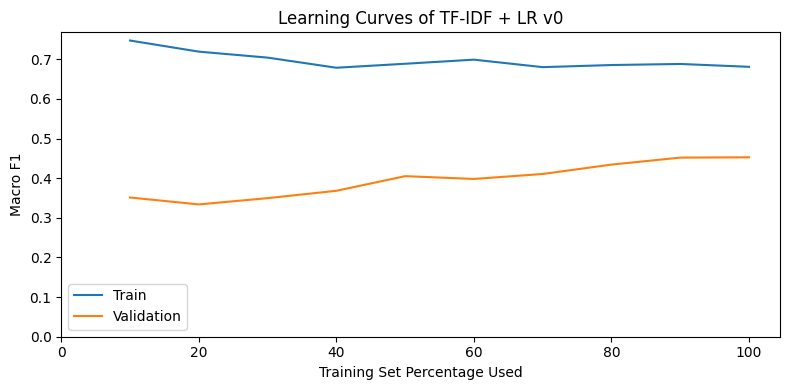

In [54]:
# Learning curves: detect overfitting by comparing train vs val F1 across training sizes (a fresh model is created here as the function retrains from scratch at each subset size)
clf = LogisticRegression(max_iter=1000, random_state=SEED)
plot_learning_curves(clf, X_train_tfidf, y_train, X_val_tfidf, y_val, "Learning Curves of TF-IDF + LR v0")

**TF-IDF + LR (v0):** The model heavily favors **Ambivalent**, missing most of **Clear Reply** and **Clear Non-Reply**. The gap between train accuracy and val accuracy (train accuracy higher tna validation one), raises the question: is the model overfitting?

To investigate, we plot **learning curves** by training on increasing subsets of the training data and evaluating on the fixed validation set at each step. The learning curves confirm **overfitting:** train F1 is significantly higher than validation F1, with the gap persisting across all training sizes, suggesting the model memorizes training patterns rather than learning generalizable features.  

In [55]:
# Save TF-IDF + LR (v0) results
results = []

report_lr_tfidf_v0_dict = classification_report(y_val, y_pred_tfidf_v0, output_dict=True)
results.append({
    "model": "TF-IDF + LR",
    "version": "default",
    "val_accuracy": round(report_lr_tfidf_v0_dict["accuracy"], 2),
    "val_precision": round(report_lr_tfidf_v0_dict["macro avg"]["precision"], 2),
    "val_recall": round(report_lr_tfidf_v0_dict["macro avg"]["recall"], 2),
    "val_f1": round(report_lr_tfidf_v0_dict["macro avg"]["f1-score"], 2)
})

## Word2Vec + Logistic Regression

###  Word2Vec Representation

In [56]:
# # Download Google News Word2Vec vectors
# import gdown

# file_id = '0B7XkCwpI5KDYNlNUTTlSS21pQmM'
# url = f'https://drive.google.com/uc?id={file_id}&resourcekey=0-wjGZdNAUop6WykTtMip30g'
# gdown.download(url, 'GoogleNews-vectors-negative300.bin.gz', quiet=False)

# # Load pretrained Word2Vec
# from gensim.models import KeyedVectors
# w2v_model = KeyedVectors.load_word2vec_format("GoogleNews-vectors-negative300.bin.gz", binary=True)

# Download via gensim
w2v_model = gensim.downloader.load("word2vec-google-news-300")

In [57]:
# Check vocab and vector sizes
print(f"Vocab size: {len(w2v_model)}")
print(f"Vector size: {w2v_model.vector_size}")

Vocab size: 3000000
Vector size: 300


In [58]:
# Test it
test_vector = w2v_model["high"]
print(f"Test vector length: {len(test_vector)}")
print(test_vector)

Test vector length: 300
[ 0.07666016  0.00970459 -0.08007812  0.18164062 -0.02624512 -0.08447266
 -0.00823975 -0.19140625  0.07373047  0.11914062 -0.05297852 -0.15136719
  0.21679688 -0.18652344  0.02661133 -0.17773438 -0.06933594  0.01190186
 -0.07226562 -0.08935547 -0.16113281  0.01324463 -0.10107422  0.1171875
  0.02099609 -0.22167969 -0.1328125   0.04833984  0.08886719 -0.28320312
  0.19433594 -0.17285156  0.3671875  -0.03198242 -0.18652344 -0.10693359
 -0.15136719 -0.12695312  0.10986328  0.11865234  0.20996094 -0.02001953
  0.08105469 -0.02172852 -0.11035156  0.04516602  0.07275391  0.20898438
  0.08154297 -0.03063965  0.14453125  0.04858398 -0.02038574  0.03857422
 -0.02429199 -0.078125   -0.33789062 -0.04760742 -0.07958984 -0.11279297
 -0.02185059  0.0625     -0.25195312 -0.03320312 -0.07128906  0.13671875
 -0.14160156  0.09863281  0.11035156  0.15234375 -0.09277344 -0.13476562
  0.08886719  0.203125   -0.14941406  0.07568359  0.16113281  0.26757812
  0.02746582  0.15527344  0.

In [59]:
# Inspect similar word to high
print(f"Most similar words to 'high': {w2v_model.most_similar('high')}")

Most similar words to 'high': [('low', 0.7421891689300537), ('High', 0.5790752172470093), ('higher', 0.569451630115509), ('highest', 0.5553146004676819), ('ahigh', 0.5219955444335938), ('lower', 0.5140001773834229), ('Low', 0.5026226043701172), ('HIGH', 0.4793128967285156), ('lowest', 0.4690744876861572), ('elevated', 0.46033966541290283)]


In [60]:
# Average Word2Vec vectors per sample
def average_embedding(text: str, model, verbose=False) -> np.ndarray:
  """
  Average word embedding vectors for all words in text.

  Args:
    text: preprocessed input string
    model: embedding model
    Verbose: enable prints if True

  Returns: 300-dim vector with zeros if no words found
  """
  words = text.split()
  vectors = [model[w] for w in words if w in model]
  if verbose:
    print(f"Text: {text}")
    print(f"Shape after embedding model: {[v.shape for v in vectors]}")
    # print(vectors)
  if vectors:
    avg_vector = np.mean(vectors, axis=0)
    if verbose:
      print(f"Shape after averaging: {avg_vector.shape}")
      print(f"First 5 averaged values: {avg_vector[:5]}\n")
    return avg_vector
  return np.zeros(w2v_model.vector_size)

In [61]:
# Test average_word_embedding func
test_sentences = ["the president said no", "clear reply"]
for s in test_sentences:
  vec = average_embedding(s, w2v_model, verbose=True)

Text: the president said no
Shape after embedding model: [(300,), (300,), (300,), (300,)]
Shape after averaging: (300,)
First 5 averaged values: [ 0.03500366 -0.05267334  0.08996582  0.00656128 -0.04348755]

Text: clear reply
Shape after embedding model: [(300,), (300,)]
Shape after averaging: (300,)
First 5 averaged values: [ 0.02770996  0.00634766 -0.08935547 -0.08129883 -0.00830078]



In [62]:
# Apply average_word_embedding
X_train_w2v = np.array([average_embedding(text, w2v_model) for text in X_train])
X_val_w2v = np.array([average_embedding(text, w2v_model) for text in X_val])

In [63]:
# Inspect shapes before and after applying embedding representation
print(f"Before Word2Vec: Train: {X_train.shape} | Val: {X_val.shape} | Type: {type(X_train)}")
print(f"After Word2Vec: Train: {X_train_w2v.shape} | Val: {X_val_w2v.shape} | Type: {type(X_train_w2v)}")

Before Word2Vec: Train: (2930,) | Val: (518,) | Type: <class 'pandas.core.series.Series'>
After Word2Vec: Train: (2930, 300) | Val: (518, 300) | Type: <class 'numpy.ndarray'>


In [64]:
# Inspect first train sample of Word2Vec vector
print(f"Text: {X_train.iloc[0][:100]}...")
print(f"Shape: {X_train_w2v[0].shape}")
print(f"First 5 values: {X_train_w2v[0][:5].round((2))}")

Text: what can you do about that? [SEP] well i really think the stock market of something i know a lot abo...
Shape: (300,)
First 5 values: [ 0.02  0.03  0.02  0.11 -0.07]


Each sample is represented by a single **300-dim vector**, obtained by: (1) splitting the text into words, (2) looking up each word in the W2V model to get its 300-dim vector, (3) averaging all word vectors into one.

### LR with Word2Vec Representation   

In [65]:
# Train LR on Word2Vec
lr_w2v_v0 = LogisticRegression(max_iter=1000, random_state=SEED)
lr_w2v_v0.fit(X_train_w2v, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [66]:
# Evaluate on train set: sanity check for overfitting
y_pred_train_w2v_v0 = lr_w2v_v0.predict(X_train_w2v)
accuracy_count(y_train, y_pred_train_w2v_v0, "train")

# Evaluate on val set
y_pred_w2v_v0 = lr_w2v_v0.predict(X_val_w2v)
accuracy_count(y_val, y_pred_w2v_v0, "val")

Train Accurracy: 1841/2930 (62.83%)
Val Accurracy: 318/518 (61.39%)


                 precision    recall  f1-score   support

     Ambivalent       0.62      0.98      0.76       306
Clear Non-Reply       0.50      0.04      0.07        54
    Clear Reply       0.61      0.11      0.18       158

       accuracy                           0.61       518
      macro avg       0.57      0.37      0.34       518
   weighted avg       0.60      0.61      0.51       518



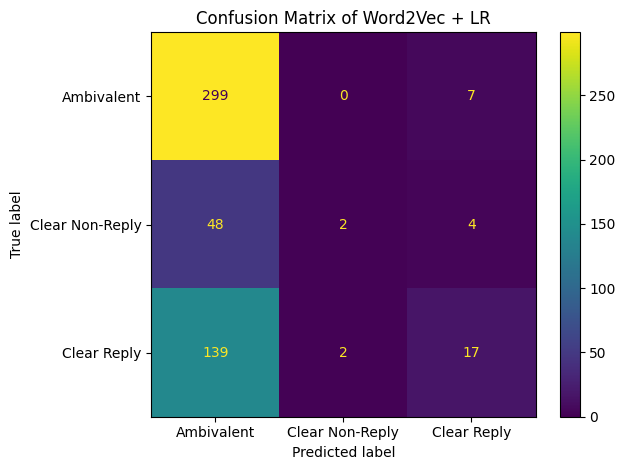

In [67]:
# Classification report with detailed metrics: accuracy, presicion, recall, f1-score
print(classification_report(y_val, y_pred_w2v_v0))

# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_w2v_v0)
plt.title("Confusion Matrix of Word2Vec + LR")
plt.tight_layout()
plt.savefig("confusion_matrix_v0_w2v.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.34 | Val F1: 0.28 | size: 293
2/10 | Train F1: 0.34 | Val F1: 0.31 | size: 586
3/10 | Train F1: 0.38 | Val F1: 0.31 | size: 879
4/10 | Train F1: 0.37 | Val F1: 0.31 | size: 1172
5/10 | Train F1: 0.36 | Val F1: 0.31 | size: 1465
6/10 | Train F1: 0.37 | Val F1: 0.32 | size: 1758
7/10 | Train F1: 0.39 | Val F1: 0.32 | size: 2051
8/10 | Train F1: 0.38 | Val F1: 0.32 | size: 2344
9/10 | Train F1: 0.38 | Val F1: 0.33 | size: 2637
10/10 | Train F1: 0.39 | Val F1: 0.34 | size: 2930


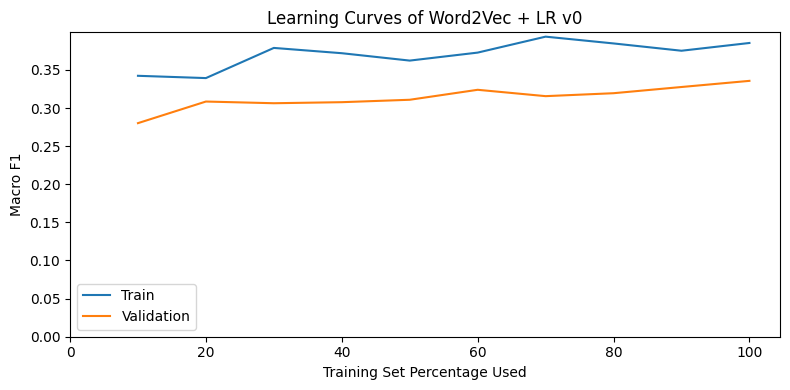

In [68]:
# Learning curves
clf = LogisticRegression(max_iter=1000, random_state=SEED)
plot_learning_curves(clf, X_train_w2v, y_train, X_val_w2v, y_val, "Learning Curves of Word2Vec + LR v0")

**Word2Vec + LR (v0):** Similar to TF-IDF + LR (v0), the model predicts **Ambivalent**, almost completely ignoring **Clear Non-Reply** and **Clear Reply**. The learning curves show both curves having very low F1 and rising together with a small gap in contrast with previous case.

In [69]:
# Save Word2Vec + LR (v0) results
report_lr_w2v_v0_dict = classification_report(y_val, y_pred_w2v_v0, output_dict=True)
results.append({
    "model": "Word2Vec + LR",
    "version": "default",
    "val_accuracy": round(report_lr_w2v_v0_dict["accuracy"], 2),
    "val_precision": round(report_lr_w2v_v0_dict["macro avg"]["precision"], 2),
    "val_recall": round(report_lr_w2v_v0_dict["macro avg"]["recall"], 2),
    "val_f1": round(report_lr_w2v_v0_dict["macro avg"]["f1-score"], 2)
})

In [70]:
# Display results of (v0)
display(pd.DataFrame(results))

,model,version,val_accuracy,val_precision,val_recall,val_f1
0,TF-IDF + LR,default,0.64,0.64,0.44,0.45
1,Word2Vec + LR,default,0.61,0.57,0.37,0.34


## Experiments

### v1: Class Weighting

Both baseline models face class imbalance. We try to address this with `class_weight="balanced"`.

#### TF-IDF + LR

In [71]:
# Train LR with class_weight="balanced"
lr_tfidf_v1 = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_tfidf_v1.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Train Accurracy: 2344/2930 (80.00%)
Val Accurracy: 329/518 (63.51%)
                 precision    recall  f1-score   support

     Ambivalent       0.74      0.68      0.71       306
Clear Non-Reply       0.41      0.56      0.47        54
    Clear Reply       0.56      0.58      0.57       158

       accuracy                           0.64       518
      macro avg       0.57      0.60      0.58       518
   weighted avg       0.65      0.64      0.64       518



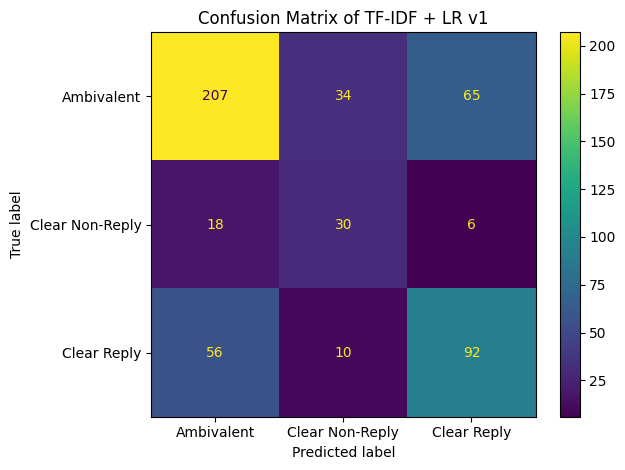

In [72]:
# Evaluate on train set
y_pred_train_tfidf_v1 = lr_tfidf_v1.predict(X_train_tfidf)
accuracy_count(y_train, y_pred_train_tfidf_v1, "train")

# Evaluate on val set
y_pred_val_tfidf_v1 = lr_tfidf_v1.predict(X_val_tfidf)
accuracy_count(y_val, y_pred_val_tfidf_v1, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_tfidf_v1))

# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_tfidf_v1)
plt.title("Confusion Matrix of TF-IDF + LR v1")
plt.tight_layout()
plt.show()

1/10 | Train F1: 0.94 | Val F1: 0.45 | size: 293
2/10 | Train F1: 0.91 | Val F1: 0.49 | size: 586
3/10 | Train F1: 0.88 | Val F1: 0.51 | size: 879
4/10 | Train F1: 0.87 | Val F1: 0.51 | size: 1172
5/10 | Train F1: 0.85 | Val F1: 0.52 | size: 1465
6/10 | Train F1: 0.83 | Val F1: 0.53 | size: 1758
7/10 | Train F1: 0.82 | Val F1: 0.54 | size: 2051
8/10 | Train F1: 0.80 | Val F1: 0.56 | size: 2344
9/10 | Train F1: 0.79 | Val F1: 0.57 | size: 2637
10/10 | Train F1: 0.79 | Val F1: 0.58 | size: 2930


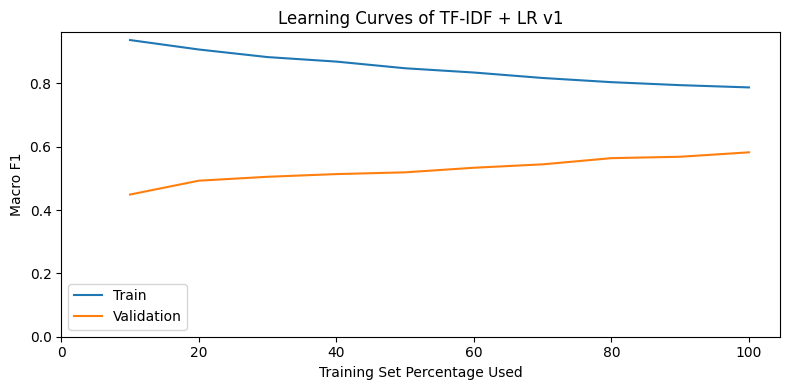

In [73]:
# Learning curves
clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
plot_learning_curves(clf, X_train_tfidf, y_train, X_val_tfidf, y_val, "Learning Curves of TF-IDF + LR v1")

In [74]:
# Save TF-IDF + LR (v1) results
report_val_tfidf_v1 = classification_report(y_val, y_pred_val_tfidf_v1, output_dict=True)
results.append({
    "model": "TF-IDF + LR",
    "version": "class_weight",
    "val_accuracy": round(report_val_tfidf_v1["accuracy"], 2),
    "val_precision": round(report_val_tfidf_v1["macro avg"]["precision"], 2),
    "val_recall": round(report_val_tfidf_v1["macro avg"]["recall"], 2),
    "val_f1": round(report_val_tfidf_v1["macro avg"]["f1-score"], 2)
})

#### Word2Vec + LR

In [75]:
# Train LR with class_weight="balanced"
lr_w2v_v1 = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_w2v_v1.fit(X_train_w2v, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Train Accurracy: 1663/2930 (56.76%)
Val Accurracy: 277/518 (53.47%)
                 precision    recall  f1-score   support

     Ambivalent       0.67      0.63      0.65       306
Clear Non-Reply       0.27      0.59      0.37        54
    Clear Reply       0.46      0.32      0.38       158

       accuracy                           0.53       518
      macro avg       0.47      0.52      0.47       518
   weighted avg       0.57      0.53      0.54       518



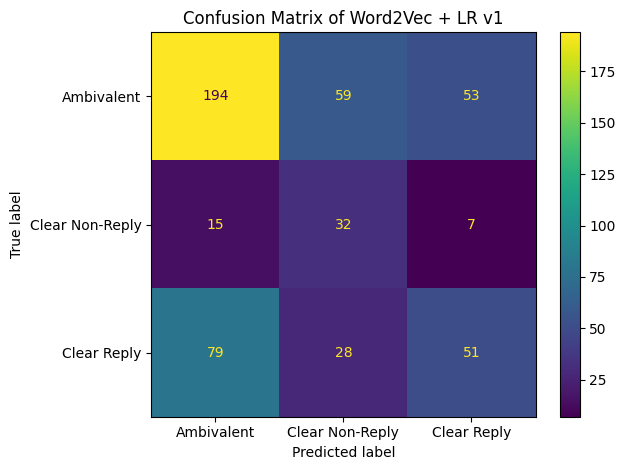

In [76]:
# Evaluate on train set
y_pred_train_w2v_v1 = lr_w2v_v1.predict(X_train_w2v)
accuracy_count(y_train, y_pred_train_w2v_v1, "train")

# Evaluate on val set
y_pred_val_w2v_v1 = lr_w2v_v1.predict(X_val_w2v)
accuracy_count(y_val, y_pred_val_w2v_v1, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_w2v_v1))

# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_w2v_v1)
plt.title("Confusion Matrix of Word2Vec + LR v1")
plt.tight_layout()
plt.show()

1/10 | Train F1: 0.58 | Val F1: 0.45 | size: 293
2/10 | Train F1: 0.56 | Val F1: 0.45 | size: 586
3/10 | Train F1: 0.53 | Val F1: 0.45 | size: 879
4/10 | Train F1: 0.53 | Val F1: 0.44 | size: 1172
5/10 | Train F1: 0.52 | Val F1: 0.45 | size: 1465
6/10 | Train F1: 0.53 | Val F1: 0.45 | size: 1758
7/10 | Train F1: 0.53 | Val F1: 0.47 | size: 2051
8/10 | Train F1: 0.52 | Val F1: 0.46 | size: 2344
9/10 | Train F1: 0.51 | Val F1: 0.47 | size: 2637
10/10 | Train F1: 0.51 | Val F1: 0.47 | size: 2930


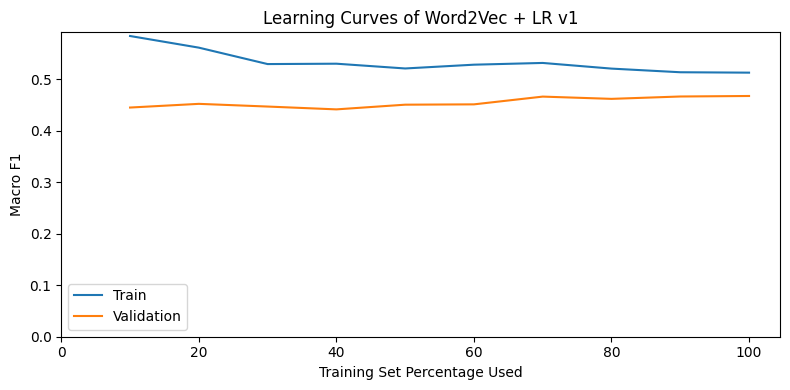

In [77]:
# Learning curves: compare v0 vs v1
clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
plot_learning_curves(clf, X_train_w2v, y_train, X_val_w2v, y_val, "Learning Curves of Word2Vec + LR v1")

In [78]:
# Save Word2Vec + LR (v1) results
report_val_w2v_v1 = classification_report(y_val, y_pred_val_w2v_v1, output_dict=True)
results.append({
    "model": "Word2Vec + LR",
    "version": "class_weight",
    "val_accuracy": round(report_val_w2v_v1["accuracy"], 2),
    "val_precision": round(report_val_w2v_v1["macro avg"]["precision"], 2),
    "val_recall": round(report_val_w2v_v1["macro avg"]["recall"], 2),
    "val_f1": round(report_val_w2v_v1["macro avg"]["f1-score"], 2)
})

In [79]:
# Display results of (v1)
display(pd.DataFrame(results))

,model,version,val_accuracy,val_precision,val_recall,val_f1
0,TF-IDF + LR,default,0.64,0.64,0.44,0.45
1,Word2Vec + LR,default,0.61,0.57,0.37,0.34
2,TF-IDF + LR,class_weight,0.64,0.57,0.60,0.58
3,Word2Vec + LR,class_weight,0.53,0.47,0.52,0.47


Adding `class_weight="balanced"` improved val F1 for both models, confirming that the class imbalance was penalizing minority classes. The learning curves show a smaller gap between train and val F1, suggesting slightly better generalization.

### v2. Representation & Hyperparameter Tuning   

Building on v1, we now tune the representation and classifier hyperparameters for both models. For TF-IDF, we tune vectorizer parameters sequentially, then tune LR on top of the best representation. For the embedding model, we first select the best embedding (GloVe vs Word2Vec), then tune LR hyperparameters on the winner.

#### TF-IDF + LR

##### Sequential TF-IDF Tuning  

In [80]:
# Tune max_features: find optimal vocabulary size on top of class weighting
max_features_list = [None, 3000, 5000, 10000, 12000]
f1_list = []

for max_f in max_features_list:
  tfidf_temp = TfidfVectorizer(max_features=max_f)
  X_tr = tfidf_temp.fit_transform(X_train)
  X_vl = tfidf_temp.transform(X_val)

  lr_temp = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
  lr_temp.fit(X_tr, y_train)

  y_pred_temp = lr_temp.predict(X_vl)
  f1 = f1_score(y_val, y_pred_temp, average="macro")
  f1_list.append(f1)
  print(f"max_features={max_f} → Val F1: {round(f1, 3)}")

best_max_features = max_features_list[np.argmax(f1_list)]
print(f"\nBest max_features: {best_max_features}")

max_features=None → Val F1: 0.582
max_features=3000 → Val F1: 0.563
max_features=5000 → Val F1: 0.58
max_features=10000 → Val F1: 0.574
max_features=12000 → Val F1: 0.577

Best max_features: None


In [81]:
# Tune word n-gram range on best_max_features
ngram_list = [(1,1), (1,2), (1,3)] # unigrams, bigrams, trigrams
f1_ngram_list = []

for ngram in ngram_list:
  tfidf_temp = TfidfVectorizer(max_features=best_max_features, ngram_range=ngram)
  X_tr = tfidf_temp.fit_transform(X_train)
  X_vl = tfidf_temp.transform(X_val)
  lr_temp = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
  lr_temp.fit(X_tr, y_train)
  f1 = f1_score(y_val, lr_temp.predict(X_vl), average="macro")
  f1_ngram_list.append(f1)
  print(f"ngram_range={ngram} → Val F1: {round(f1, 3)}")

best_ngram = ngram_list[np.argmax(f1_ngram_list)]
print(f"\nBest ngram_range: {best_ngram} | Vocab size: {tfidf_temp.get_feature_names_out().shape[0]}")

ngram_range=(1, 1) → Val F1: 0.582
ngram_range=(1, 2) → Val F1: 0.605
ngram_range=(1, 3) → Val F1: 0.61

Best ngram_range: (1, 3) | Vocab size: 502210


In [82]:
# Show unconstrained vocab size per ngram range
for ngram in ngram_list:
  tfidf_temp_full = TfidfVectorizer(ngram_range=ngram)  # no max_features
  tfidf_temp_full.fit(X_train)
  print(f"ngram_range={ngram} → Full vocab size: {tfidf_temp_full.get_feature_names_out().shape[0]}")

# Sample tkens per ngram type
feature_names_ngram = tfidf_temp.get_feature_names_out()
unigrams = [f for f in feature_names_ngram if len(f.split()) == 1][500:505]
bigrams = [f for f in feature_names_ngram if len(f.split()) == 2][500:505]
trigrams = [f for f in feature_names_ngram if len(f.split()) == 3][500:505]

print("\nSample unigrams:", unigrams)
print("Sample bigrams:", bigrams)
print("Sample trigrams:", trigrams)

ngram_range=(1, 1) → Full vocab size: 13501
ngram_range=(1, 2) → Full vocab size: 163825
ngram_range=(1, 3) → Full vocab size: 502210

Sample unigrams: ['africans', 'africom', 'after', 'aftermath', 'afternoon']
Sample bigrams: ['2030 sep', '2030 they', '2030 to', '2030 we', '20302030 countries']
Sample trigrams: ['1971 the filibuster', '1972 in poland', '1979 and that', '1980 let see', '1981 on the']


In [83]:
# Tune sublinear_tf, min_df, max_df for word n-gram vectorizer only
configs = [
    {"sublinear_tf": False, "min_df": 1, "max_df": 1.0},
    {"sublinear_tf": True, "min_df": 1, "max_df": 1.0},
    {"sublinear_tf": True, "min_df": 2, "max_df": 0.95},
    {"sublinear_tf": True, "min_df": 3, "max_df": 0.90},
]
f1_config_list = []

for cfg in configs:
  tfidf_temp = TfidfVectorizer(max_features=best_max_features, ngram_range=best_ngram, sublinear_tf=cfg["sublinear_tf"], min_df=cfg["min_df"], max_df=cfg["max_df"])
  X_tr = tfidf_temp.fit_transform(X_train)
  X_vl = tfidf_temp.transform(X_val)

  lr_temp = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
  lr_temp.fit(X_tr, y_train)

  f1 = f1_score(y_val, lr_temp.predict(X_vl), average="macro")
  f1_config_list.append(f1)
  print(f"sublinear={cfg['sublinear_tf']}  min_df={cfg['min_df']}  max_df={cfg['max_df']} → F1: {f1:.3f}")

best_cfg = configs[np.argmax(f1_config_list)]
print(f"\nBest config: {best_cfg}")

sublinear=False  min_df=1  max_df=1.0 → F1: 0.610
sublinear=True  min_df=1  max_df=1.0 → F1: 0.620
sublinear=True  min_df=2  max_df=0.95 → F1: 0.620
sublinear=True  min_df=3  max_df=0.9 → F1: 0.623

Best config: {'sublinear_tf': True, 'min_df': 3, 'max_df': 0.9}


##### LR Hyperparameter Tuning   

In [84]:
# Build best TF-IDF representation from sequential tuning
tfidf_v2 = TfidfVectorizer(
    max_features=best_max_features,
    ngram_range=best_ngram,
    sublinear_tf=best_cfg["sublinear_tf"],
    min_df=best_cfg["min_df"],
    max_df=best_cfg["max_df"]
)
X_train_tfidf_v2 = tfidf_v2.fit_transform(X_train)
X_val_tfidf_v2 = tfidf_v2.transform(X_val)

In [ ]:
# # Custom Grid search over C, solver, and penalty on fixed val set (l1 penalty is only supported by the liblinear solver)
# C_values = [0.5, 1, 5, 10] # 0.1
# solvers = ["lbfgs", "liblinear"]
# penalties = ["l1", "l2"]

# best_f1_tfidf_v2 = 0
# best_params_tfidf_v2 = {}

# for C in C_values:
#   for solver in solvers:
#     for penalty in penalties:
#       if penalty == "l1" and solver != "liblinear":
#         continue
#       lr_temp = LogisticRegression(C=C, solver=solver, penalty=penalty, max_iter=1000, random_state=SEED, class_weight="balanced")
#       lr_temp.fit(X_train_tfidf_v2, y_train)
#       f1 = f1_score(y_val, lr_temp.predict(X_val_tfidf_v2), average="macro")
#       if f1 > best_f1_tfidf_v2:
#         best_f1_tfidf_v2 = f1
#         best_params_tfidf_v2 = {"C": C, "solver": solver, "penalty": penalty}

# print("Best params:", best_params_tfidf_v2)
# print("Best val F1:", round(best_f1_tfidf_v2, 3))

Best params: {'C': 1, 'solver': 'lbfgs', 'penalty': 'l2'}
Best val F1: 0.623


In [85]:
# Hardcoded best params from LR hyperparameter search (cell above)
best_params_tfidf_v2 = {"C": 1, "solver": "lbfgs", "penalty": "l2"}
best_f1_tfidf_v2 = 0.623

A smaller C applies stronger regularization, reducing the risk of overfitting, while a larger C allows the model to fit training data more closely at the risk of memorizing noise. Given the overfitting gap observed in the TF-IDF + LR (v1) learning curves, we would expect a smaller C to perform best. If instead higher C values are selected, this indicates that `class_weight="balanced"` and IDF weighting already act as implicit regularization, making additional regularization from a small C unnecessary and potentially harmful to minority class detection.

In [86]:
# Refit LR on fixed split with best params from hyperparameter search
lr_tfidf_v2 = LogisticRegression(
    C=best_params_tfidf_v2["C"], solver=best_params_tfidf_v2["solver"],
    penalty=best_params_tfidf_v2["penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_tfidf_v2.fit(X_train_tfidf_v2, y_train)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42)

Train Accurracy: 2512/2930 (85.73%)
Val Accurracy: 342/518 (66.02%)
                 precision    recall  f1-score   support

     Ambivalent       0.73      0.74      0.73       306
Clear Non-Reply       0.59      0.61      0.60        54
    Clear Reply       0.55      0.53      0.54       158

       accuracy                           0.66       518
      macro avg       0.62      0.62      0.62       518
   weighted avg       0.66      0.66      0.66       518



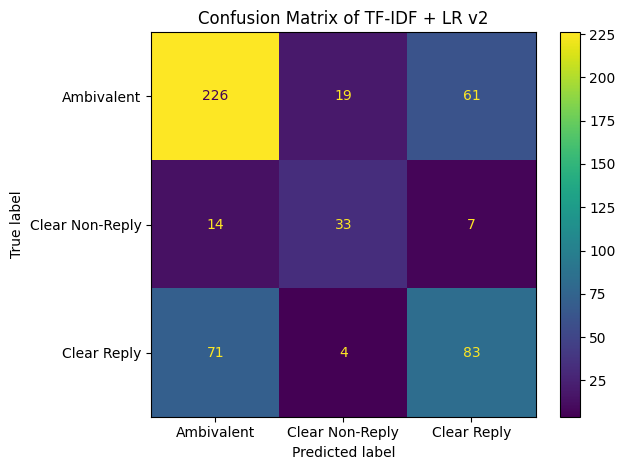

In [87]:
# Evaluate on train set
y_pred_train_tfidf_v2 = lr_tfidf_v2.predict(X_train_tfidf_v2)
accuracy_count(y_train, y_pred_train_tfidf_v2, "train")

# Evaluate on val set
y_pred_val_tfidf_v2 = lr_tfidf_v2.predict(X_val_tfidf_v2)
accuracy_count(y_val, y_pred_val_tfidf_v2, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_tfidf_v2))

# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_tfidf_v2)
plt.title("Confusion Matrix of TF-IDF + LR v2")
plt.tight_layout()
plt.savefig("confusion_matrix_v2_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.99 | Val F1: 0.45 | size: 293
2/10 | Train F1: 0.97 | Val F1: 0.49 | size: 586
3/10 | Train F1: 0.95 | Val F1: 0.52 | size: 879
4/10 | Train F1: 0.93 | Val F1: 0.53 | size: 1172
5/10 | Train F1: 0.92 | Val F1: 0.55 | size: 1465
6/10 | Train F1: 0.90 | Val F1: 0.57 | size: 1758
7/10 | Train F1: 0.88 | Val F1: 0.59 | size: 2051
8/10 | Train F1: 0.87 | Val F1: 0.59 | size: 2344
9/10 | Train F1: 0.86 | Val F1: 0.60 | size: 2637
10/10 | Train F1: 0.85 | Val F1: 0.62 | size: 2930


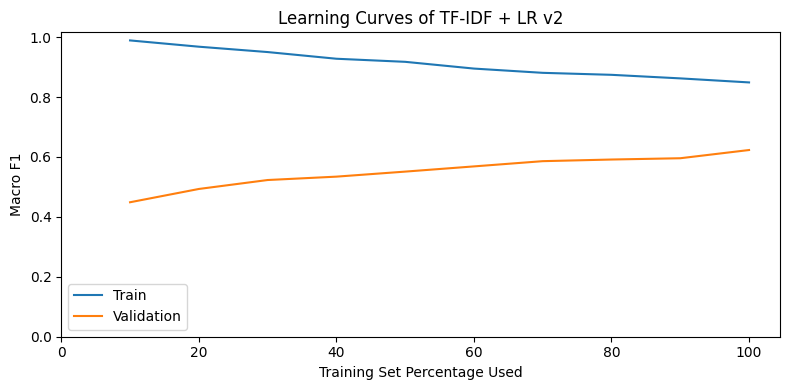

In [88]:
# Learning curves
plot_learning_curves(lr_tfidf_v2, X_train_tfidf_v2, y_train, X_val_tfidf_v2, y_val, "Learning Curves of TF-IDF + LR v2")

In [89]:
# Save TF-IDF + LR (v2) results
report_val_tfidf_v2 = classification_report(y_val, y_pred_val_tfidf_v2, output_dict=True)
results.append({
    "model": "TF-IDF + LR",
    "version": "repr_tuning+lr_tuning",
    "val_accuracy": round(report_val_tfidf_v2["accuracy"], 2),
    "val_precision": round(report_val_tfidf_v2["macro avg"]["precision"], 2),
    "val_recall": round(report_val_tfidf_v2["macro avg"]["recall"], 2),
    "val_f1": round(report_val_tfidf_v2["macro avg"]["f1-score"], 2)
})

TF-IDF and Logistic Regression parameters were tuned sequentially: first the vectorizer parameters, and then the Logistic Regression parameters on top of the fixed best representation. Compared with v1, this approach yields a slightly higher validation F1 while maintaining a similar generalization gap (as observed in the training and validation curves). This sequential strategy is fast and interpretable, but it is suboptimal because the best value for one parameter may shift when other parameters change. This interaction effect motivates the joint search in v3.

#### Word2Vec + LR

##### GloVe vs Word2Vec

In [90]:
# Check all available models in gensim downloader
print(list(gensim.downloader.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [91]:
# Load GloVe
glove_model = gensim.downloader.load("glove-wiki-gigaword-300")
print(f"Vocab size: {len(glove_model)}")
print(f"Vector size: {glove_model.vector_size}")

Vocab size: 400000
Vector size: 300


In [92]:
# Build GloVe averaged vectors
X_train_glove = np.array([average_embedding(t, glove_model) for t in X_train])
X_val_glove = np.array([average_embedding(t, glove_model) for t in X_val])

print(f"Shapes: Train: {X_train_glove.shape} | Val: {X_val_glove.shape}")

Shapes: Train: (2930, 300) | Val: (518, 300)


In [93]:
# Compare the two embedding models with class weighting
emb_names = ["W2V (Google News)", "GloVe"]
emb_trains = [X_train_w2v, X_train_glove]
emb_vals = [X_val_w2v, X_val_glove]

f1_emb_list = []

for name, X_tr, X_vl in zip(emb_names, emb_trains, emb_vals):
  lr_temp = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
  lr_temp.fit(X_tr, y_train)
  f1 = f1_score(y_val, lr_temp.predict(X_vl), average="macro")
  f1_emb_list.append(f1)
  print(f"{name} → Val F1: {f1:.3f}")

best_emb_idx = np.argmax(f1_emb_list)
best_emb_name = emb_names[best_emb_idx]

X_train_w2v_v2 = emb_trains[best_emb_idx]
X_val_w2v_v2 = emb_vals[best_emb_idx]

print(f"\nBest embedding: {best_emb_name}")
best_emb_model = glove_model if best_emb_name == "GloVe" else w2v_model

W2V (Google News) → Val F1: 0.467
GloVe → Val F1: 0.483

Best embedding: GloVe


In [94]:
# Train best performing embedding model with class weighting
lr_w2v_v2 = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_w2v_v2.fit(X_train_w2v_v2, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Train Accurracy: 1684/2930 (57.47%)
Val Accurracy: 269/518 (51.93%)
                 precision    recall  f1-score   support

     Ambivalent       0.67      0.55      0.60       306
Clear Non-Reply       0.31      0.63      0.42        54
    Clear Reply       0.42      0.43      0.43       158

       accuracy                           0.52       518
      macro avg       0.47      0.54      0.48       518
   weighted avg       0.56      0.52      0.53       518



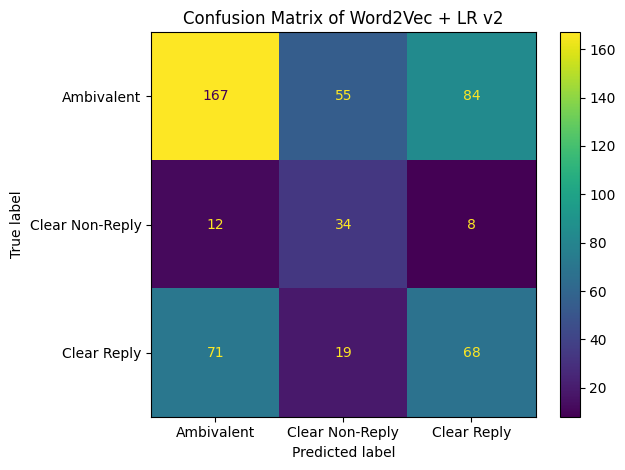

In [95]:
# Evaluate on train set
y_pred_train_w2v_v2 = lr_w2v_v2.predict(X_train_w2v_v2)
accuracy_count(y_train, y_pred_train_w2v_v2,"train")

# Evaluate on val set
y_pred_val_w2v_v2 = lr_w2v_v2.predict(X_val_w2v_v2)
accuracy_count(y_val, y_pred_val_w2v_v2, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_w2v_v2))

# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_w2v_v2)
plt.title("Confusion Matrix of Word2Vec + LR v2")
plt.tight_layout()
plt.savefig("confusion_matrix_v2_w2v.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.65 | Val F1: 0.45 | size: 293
2/10 | Train F1: 0.62 | Val F1: 0.46 | size: 586
3/10 | Train F1: 0.58 | Val F1: 0.48 | size: 879
4/10 | Train F1: 0.56 | Val F1: 0.46 | size: 1172
5/10 | Train F1: 0.55 | Val F1: 0.46 | size: 1465
6/10 | Train F1: 0.55 | Val F1: 0.46 | size: 1758
7/10 | Train F1: 0.55 | Val F1: 0.46 | size: 2051
8/10 | Train F1: 0.55 | Val F1: 0.48 | size: 2344
9/10 | Train F1: 0.54 | Val F1: 0.48 | size: 2637
10/10 | Train F1: 0.54 | Val F1: 0.48 | size: 2930


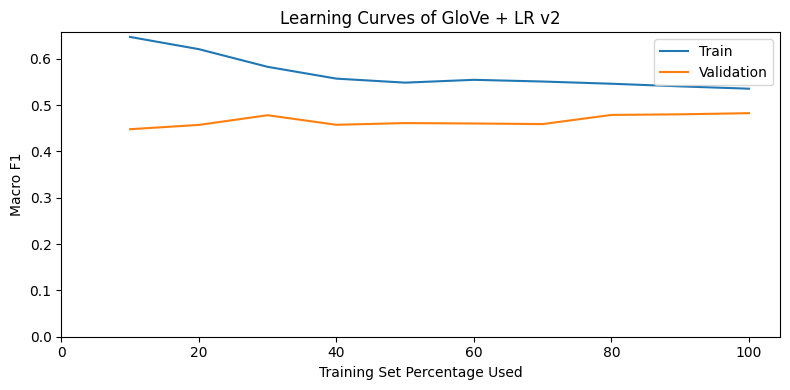

In [96]:
# Learning curves
clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
plot_learning_curves(clf, X_train_w2v_v2, y_train, X_val_w2v_v2, y_val, f"Learning Curves of {best_emb_name} + LR v2")

**Best Embedding + LR (v2):** Slightly outperforms Word2Vec with class weighting (F1). The learning curves show the same small but stable gap with Word2Vec + LR (v1).

##### LR Hyperparameter Tuning

In [ ]:
# # Word2Vec + LR: hyperparameter tuning with CV and scaling
# pipeline_w2v = Pipeline([
#     # ("scaler", StandardScaler()), # tested with scaling: CV F1=0.457 vs without: CV F1=0.481
#     ("lr", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
# ])

# param_grid_w2v = [
#     {
#         "lr__C": [5, 10, 15], # 50
#         "lr__penalty": ["l2"],
#         "lr__solver": ["lbfgs", "liblinear"],
#     },
#     {
#         "lr__C": [5, 10, 15], # 50
#         "lr__penalty": ["l1"],
#         "lr__solver": ["liblinear"],
#     },
# ]

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# gs_w2v = GridSearchCV(
#     pipeline_w2v,
#     param_grid_w2v,
#     cv=cv,
#     scoring="f1_macro",
#     n_jobs=1,
#     verbose=1
# )

# # Build full train embeddings for CV
# X_full_w2v = np.array([average_embedding(t, best_emb_model) for t in train_df["input"]])
# gs_w2v.fit(X_full_w2v, train_df["clarity_label"])

# print(f"Best CV F1: {gs_w2v.best_score_:.3f}")
# print(f"Best params: {gs_w2v.best_params_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best CV F1: 0.481
Best params: {'lr__C': 10, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}


In [97]:
# Extract best params from CV search
# best_params_w2v_v2_cv = gs_w2v.best_params_
# best_f1_w2v_v2_cv = gs_w2v.best_score_

# Hardcoded best params from CV search (cell above)
best_params_w2v_v2_cv = {"lr__C": 10, "lr__penalty": "l2", "lr__solver": "liblinear"}
best_f1_w2v_v2_cv = 0.481

In [98]:
# Refit with CV-selected params on fixed split (for visualization only, not for decision-making)
# scaler_w2v = StandardScaler()
# X_train_w2v_v2_scaled = scaler_w2v.fit_transform(X_train_w2v_v2)
# X_val_w2v_v2_scaled = scaler_w2v.transform(X_val_w2v_v2)

lr_w2v_v2 = LogisticRegression(
    C=best_params_w2v_v2_cv["lr__C"], solver=best_params_w2v_v2_cv["lr__solver"],
    penalty=best_params_w2v_v2_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_w2v_v2.fit(X_train_w2v_v2, y_train)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   random_state=42, solver='liblinear')

Train Accurracy: 1930/2930 (65.87%)
Val Accurracy: 303/518 (58.49%)
                 precision    recall  f1-score   support

     Ambivalent       0.64      0.77      0.70       306
Clear Non-Reply       0.44      0.46      0.45        54
    Clear Reply       0.45      0.26      0.33       158

       accuracy                           0.58       518
      macro avg       0.51      0.50      0.49       518
   weighted avg       0.56      0.58      0.56       518



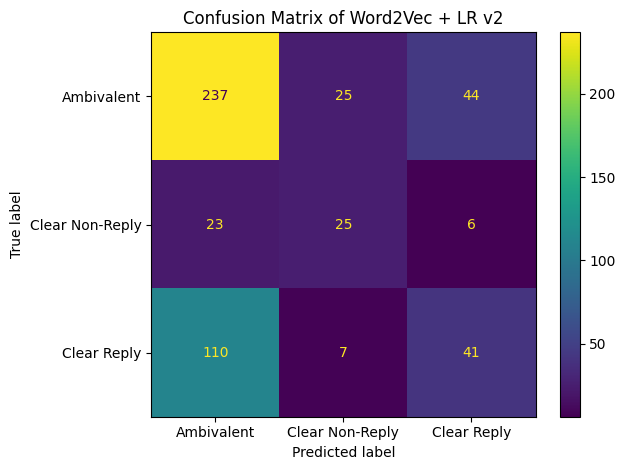

In [99]:
# Evaluate on train set
y_pred_train_w2v_v2 = lr_w2v_v2.predict(X_train_w2v_v2)
accuracy_count(y_train, y_pred_train_w2v_v2, "train")

# Evaluate on val set
y_pred_val_w2v_v2 = lr_w2v_v2.predict(X_val_w2v_v2)
accuracy_count(y_val, y_pred_val_w2v_v2, "val")

# Classification report
print(classification_report(y_val, y_pred_val_w2v_v2))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_w2v_v2)
plt.title("Confusion Matrix of Word2Vec + LR v2")
plt.tight_layout()
plt.savefig("confusion_matrix_v2_w2v.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.79 | Val F1: 0.48 | size: 293
2/10 | Train F1: 0.75 | Val F1: 0.48 | size: 586
3/10 | Train F1: 0.70 | Val F1: 0.47 | size: 879
4/10 | Train F1: 0.66 | Val F1: 0.48 | size: 1172
5/10 | Train F1: 0.63 | Val F1: 0.48 | size: 1465
6/10 | Train F1: 0.62 | Val F1: 0.49 | size: 1758
7/10 | Train F1: 0.62 | Val F1: 0.49 | size: 2051
8/10 | Train F1: 0.61 | Val F1: 0.50 | size: 2344
9/10 | Train F1: 0.59 | Val F1: 0.51 | size: 2637
10/10 | Train F1: 0.59 | Val F1: 0.49 | size: 2930


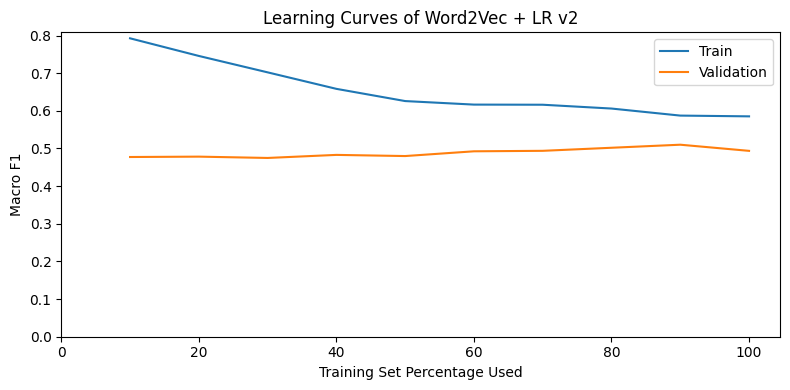

In [100]:
# Learning curves
plot_learning_curves(lr_w2v_v2, X_train_w2v_v2, y_train, X_val_w2v_v2, y_val, "Learning Curves of Word2Vec + LR v2")

**Best Embedding + LR (v2):** Hyperparameter tuning yields a slight F1 improvement over v1, while the learning curves show a similar pattern: both curves remain close together throughout training, confirming the better generalization characteristic of dense embedding representations compared to TF-IDF.

In [101]:
# Save Word2Vec + LR (v2) results
report_val_w2v_v2 = classification_report(y_val, y_pred_val_w2v_v2, output_dict=True)
results.append({
    "model": "Word2Vec + LR",
    "version": f"{best_emb_name}+lr_tuning",
    "val_accuracy": round(report_val_w2v_v2["accuracy"], 2),
    "val_precision": round(report_val_w2v_v2["macro avg"]["precision"], 2),
    "val_recall": round(report_val_w2v_v2["macro avg"]["recall"], 2),
    "val_f1": round(report_val_w2v_v2["macro avg"]["f1-score"], 2)
})

In [102]:
# Display results of (v2)
display(pd.DataFrame(results))

,model,version,val_accuracy,val_precision,val_recall,val_f1
0,TF-IDF + LR,default,0.64,0.64,0.44,0.45
1,Word2Vec + LR,default,0.61,0.57,0.37,0.34
2,TF-IDF + LR,class_weight,0.64,0.57,0.60,0.58
3,Word2Vec + LR,class_weight,0.53,0.47,0.52,0.47
4,TF-IDF + LR,repr_tuning+lr_tuning,0.66,0.62,0.62,0.62
5,Word2Vec + LR,GloVe+lr_tuning,0.58,0.51,0.50,0.49


### v3. TF-IDF Hyperparameter Tuning using Joint Grid Search

#### Joint Search on Fixed Validation Set

In [ ]:
# # TF-IDF + LR: joint search over vectorizer + classifier params on fixed val set
# max_features_values = [None, 10000, 50000] # 100000
# ngram_values = [(1, 2), (1, 3)] # (1, 1)
# sublinear_values = [True] # False is excluded as in all trials, we get True
# penalty_values = ["l2"] # "l1" because it never won in TF-IDF experiments
# min_df_values = [2, 3] # 1
# max_df_values = [0.90, 0.95] # 1.0
# C_values = [0.5, 1, 5, 10]
# solvers = ["lbfgs", "liblinear"]

# best_f1_v3_fixed = 0
# best_params_v3_fixed = {}

# combinations = list(product(max_features_values, ngram_values, sublinear_values, penalty_values, min_df_values, max_df_values, C_values, solvers))

# for max_feat, ngram, sublinear, penalty, min_df, max_df, C, solver in tqdm(combinations):
#   if penalty == "l1" and solver != "liblinear":
#     continue
#   tfidf_temp = TfidfVectorizer(max_features=max_feat, ngram_range=ngram, sublinear_tf=sublinear, min_df=min_df, max_df=max_df)
#   X_tr = tfidf_temp.fit_transform(X_train)
#   X_vl = tfidf_temp.transform(X_val)

#   lr_temp = LogisticRegression(C=C, solver=solver, penalty=penalty, max_iter=1000, random_state=SEED, class_weight="balanced")
#   lr_temp.fit(X_tr, y_train)
#   f1 = f1_score(y_val, lr_temp.predict(X_vl), average="macro")

#   if f1 > best_f1_v3_fixed:
#     best_f1_v3_fixed = f1
#     best_params_v3_fixed = {"max_features": max_feat, "ngram_range": ngram, "sublinear_tf": sublinear, "min_df": min_df, "max_df": max_df, "C": C, "solver": solver, "penalty": penalty}

# print("Best params:", best_params_v3_fixed)
# print("Best val F1:", round(best_f1_v3_fixed, 3))

100%|██████████| 192/192 [23:12<00:00,  7.25s/it]

Best params: {'max_features': None, 'ngram_range': (1, 2), 'sublinear_tf': True, 'min_df': 2, 'max_df': 0.9, 'C': 5, 'solver': 'liblinear', 'penalty': 'l2'}
Best val F1: 0.631


In [103]:
# Hardcoded best params from fixed val set joint search (cell above)
best_params_v3_fixed = {
    "max_features": None,
    "ngram_range": (1, 2),
    "sublinear_tf": True,
    "min_df": 2,
    "max_df": 0.9,
    "C": 5,
    "solver": "liblinear",
    "penalty": "l2"
}
best_f1_v3_fixed = 0.631

In [104]:
# Refit TF-IDF with best params from joint search
tfidf_v3_fixed = TfidfVectorizer(
    max_features=best_params_v3_fixed["max_features"],
    ngram_range=best_params_v3_fixed["ngram_range"],
    sublinear_tf=best_params_v3_fixed["sublinear_tf"],
    min_df=best_params_v3_fixed["min_df"],
    max_df = best_params_v3_fixed["max_df"]
)
X_train_tfidf_v3_fixed = tfidf_v3_fixed.fit_transform(X_train)
X_val_tfidf_v3_fixed = tfidf_v3_fixed.transform(X_val)
print(f"Vocabulary size: {tfidf_v3_fixed.get_feature_names_out().shape[0]}")

Vocabulary size: 107627


In [105]:
# Train LR with best params from joint search
lr_tfidf_v3_fixed = LogisticRegression(
    C=best_params_v3_fixed["C"], solver=best_params_v3_fixed["solver"],
    penalty=best_params_v3_fixed["penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_tfidf_v3_fixed.fit(X_train_tfidf_v3_fixed, y_train)

LogisticRegression(C=5, class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

Train Accurracy: 2647/2930 (90.34%)
Val Accurracy: 354/518 (68.34%)
                 precision    recall  f1-score   support

     Ambivalent       0.72      0.81      0.76       306
Clear Non-Reply       0.67      0.54      0.60        54
    Clear Reply       0.59      0.48      0.53       158

       accuracy                           0.68       518
      macro avg       0.66      0.61      0.63       518
   weighted avg       0.68      0.68      0.67       518



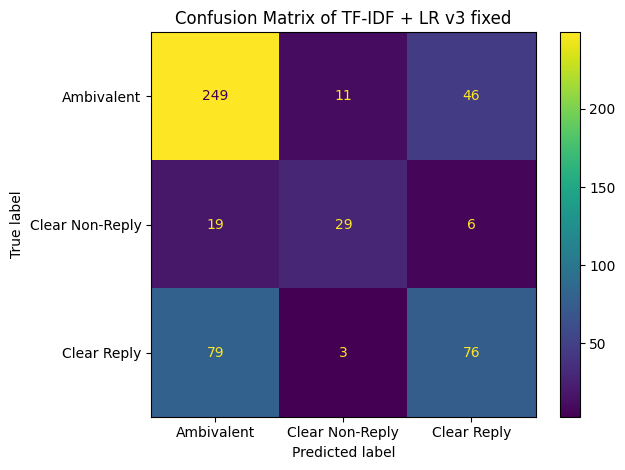

In [106]:
# Evaluate on train set
y_pred_train_tfidf_v3_fixed = lr_tfidf_v3_fixed.predict(X_train_tfidf_v3_fixed)
accuracy_count(y_train, y_pred_train_tfidf_v3_fixed, "train")

# Evaluate on val set
y_pred_val_tfidf_v3_fixed = lr_tfidf_v3_fixed.predict(X_val_tfidf_v3_fixed)
accuracy_count(y_val, y_pred_val_tfidf_v3_fixed, "val")

# Classification report with detailed metrics
print(classification_report(y_val, y_pred_val_tfidf_v3_fixed))

# Confusion matrix for visual error analysis
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_tfidf_v3_fixed)
plt.title("Confusion Matrix of TF-IDF + LR v3 fixed")
plt.tight_layout()
plt.savefig("confusion_matrix_v3_fixed_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.99 | Val F1: 0.43 | size: 293
2/10 | Train F1: 0.97 | Val F1: 0.46 | size: 586
3/10 | Train F1: 0.96 | Val F1: 0.49 | size: 879
4/10 | Train F1: 0.95 | Val F1: 0.52 | size: 1172
5/10 | Train F1: 0.94 | Val F1: 0.54 | size: 1465
6/10 | Train F1: 0.93 | Val F1: 0.58 | size: 1758
7/10 | Train F1: 0.92 | Val F1: 0.59 | size: 2051
8/10 | Train F1: 0.91 | Val F1: 0.60 | size: 2344
9/10 | Train F1: 0.90 | Val F1: 0.62 | size: 2637
10/10 | Train F1: 0.90 | Val F1: 0.63 | size: 2930


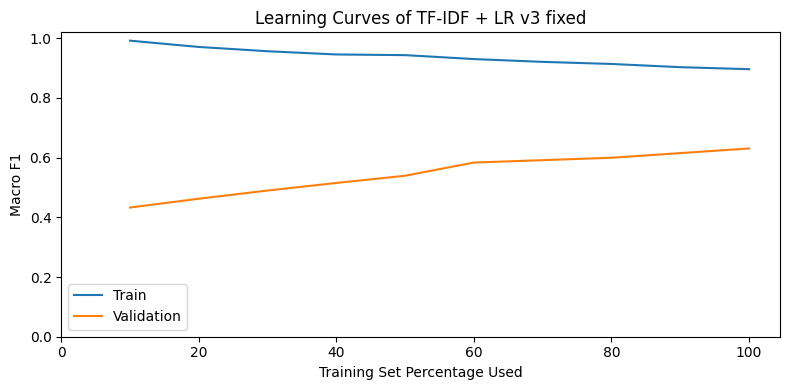

In [107]:
# Learning curves
plot_learning_curves(lr_tfidf_v3_fixed, X_train_tfidf_v3_fixed, y_train, X_val_tfidf_v3_fixed, y_val, "Learning Curves of TF-IDF + LR v3 fixed")

In [108]:
# Save TF-IDF + LR (v3 fixed) results
report_val_tfidf_v3_fixed = classification_report(y_val, y_pred_val_tfidf_v3_fixed, output_dict=True)
results.append({
    "model": "TF-IDF + LR",
    "version": "joint_repr_lr_tuning_fixed",
    "val_accuracy": round(report_val_tfidf_v3_fixed["accuracy"], 2),
    "val_precision": round(report_val_tfidf_v3_fixed["macro avg"]["precision"], 2),
    "val_recall": round(report_val_tfidf_v3_fixed["macro avg"]["recall"], 2),
    "val_f1": round(report_val_tfidf_v3_fixed["macro avg"]["f1-score"], 2)
})

#### Joint Search with Cross-Validation

In [ ]:
# # TF-IDF + LR: joint search over vectorizer + classifier params with CV
# pipeline = Pipeline([
#     ("tfidf", TfidfVectorizer()),
#     ("lr", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
# ])

# param_grid = {
#     "tfidf__ngram_range": [(1, 2), (1,3)],
#     "tfidf__max_features": [None, 10000, 50000],
#     "tfidf__sublinear_tf": [True],
#     "tfidf__min_df": [2, 3],
#     "tfidf__max_df": [0.90, 0.95],
#     "lr__C": [0.5, 1, 5, 10],
#     "lr__penalty": ["l2"],
#     "lr__solver": ["lbfgs", "liblinear"],
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# gs = GridSearchCV(
#     pipeline,
#     param_grid,
#     cv=cv,
#     scoring="f1_macro",
#     n_jobs=-1,
#     verbose=1
# )

# # Fit on FULL train_df (CV creates its own internal folds)
# gs.fit(train_df["input"], train_df["clarity_label"])

# print(f"Best CV F1: {gs.best_score_:.3f}")
# print(f"Best params: {gs.best_params_}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best CV F1: 0.547
Best params: {'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs', 'tfidf__max_df': 0.95, 'tfidf__max_features': None, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}


In [109]:
# Hardcoded best params from CV joint search (cell above)
best_params_v3_cv = {
    "tfidf__max_features": None,
    "tfidf__ngram_range": (1, 3),
    "tfidf__sublinear_tf": True,
    "tfidf__min_df": 2,
    "tfidf__max_df": 0.95,
    "lr__C": 1,
    "lr__solver": "lbfgs",
    "lr__penalty": "l2"
}
best_f1_v3_cv = 0.547

In [110]:
# Refit on existing fixed split for visualization purposes
tfidf_v3 = TfidfVectorizer(
    max_features=best_params_v3_cv["tfidf__max_features"],
    ngram_range=best_params_v3_cv["tfidf__ngram_range"],
    sublinear_tf=best_params_v3_cv["tfidf__sublinear_tf"],
    min_df=best_params_v3_cv["tfidf__min_df"],
    max_df=best_params_v3_cv["tfidf__max_df"]
)
X_train_tfidf_v3 = tfidf_v3.fit_transform(X_train)
X_val_tfidf_v3 = tfidf_v3.transform(X_val)

lr_tfidf_v3 = LogisticRegression(
    C=best_params_v3_cv["lr__C"], solver=best_params_v3_cv["lr__solver"],
    penalty=best_params_v3_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_tfidf_v3.fit(X_train_tfidf_v3, y_train)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42)

Train Accurracy: 2518/2930 (85.94%)
Val Accurracy: 343/518 (66.22%)
                 precision    recall  f1-score   support

     Ambivalent       0.73      0.75      0.74       306
Clear Non-Reply       0.61      0.56      0.58        54
    Clear Reply       0.55      0.53      0.54       158

       accuracy                           0.66       518
      macro avg       0.63      0.61      0.62       518
   weighted avg       0.66      0.66      0.66       518



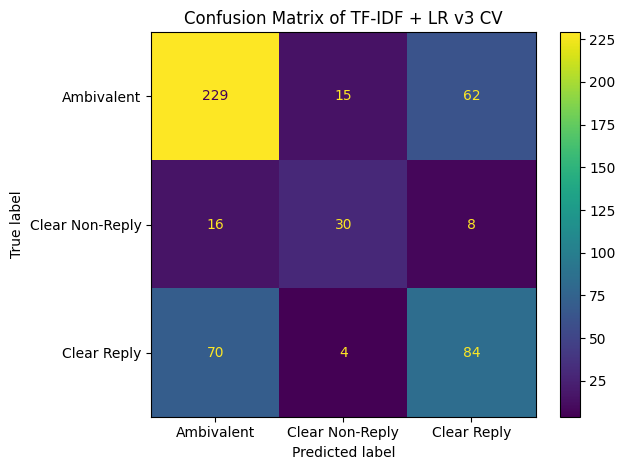

In [111]:
# Evaluate on train set
y_pred_train_tfidf_v3 = lr_tfidf_v3.predict(X_train_tfidf_v3)
accuracy_count(y_train, y_pred_train_tfidf_v3, "train")

# Evaluate on val set
y_pred_val_tfidf_v3 = lr_tfidf_v3.predict(X_val_tfidf_v3)
accuracy_count(y_val, y_pred_val_tfidf_v3, "val")

# Classification report
print(classification_report(y_val, y_pred_val_tfidf_v3))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val_tfidf_v3)
plt.title("Confusion Matrix of TF-IDF + LR v3 CV")
plt.tight_layout()
plt.savefig("confusion_matrix_v3_cv_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

1/10 | Train F1: 0.99 | Val F1: 0.44 | size: 293
2/10 | Train F1: 0.97 | Val F1: 0.48 | size: 586
3/10 | Train F1: 0.95 | Val F1: 0.51 | size: 879
4/10 | Train F1: 0.93 | Val F1: 0.54 | size: 1172
5/10 | Train F1: 0.92 | Val F1: 0.56 | size: 1465
6/10 | Train F1: 0.90 | Val F1: 0.58 | size: 1758
7/10 | Train F1: 0.89 | Val F1: 0.59 | size: 2051
8/10 | Train F1: 0.88 | Val F1: 0.60 | size: 2344
9/10 | Train F1: 0.86 | Val F1: 0.60 | size: 2637
10/10 | Train F1: 0.85 | Val F1: 0.62 | size: 2930


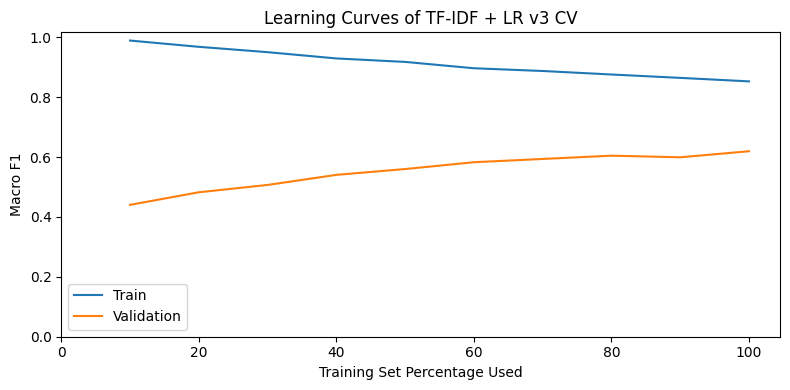

In [112]:
# Learning curves
plot_learning_curves(lr_tfidf_v3, X_train_tfidf_v3, y_train, X_val_tfidf_v3, y_val, "Learning Curves of TF-IDF + LR v3 CV")

The fixed split search reports a higher F1, but cross-validation reveals a true performance with lower F1 and a better generalization gap. This confirms that the fixed-split score was inflated by overfitting to that specific validation set.

We adopt the CV-selected parameters for the final model, as they provide a more reliable estimate of generalization performance.

In [113]:
# Save TF-IDF + LR (v3 CV) results
report_val_tfidf_v3 = classification_report(y_val, y_pred_val_tfidf_v3, output_dict=True)
results.append({
    "model": "TF-IDF + LR",
    "version": "joint_repr_lr_tuning_cv",
    "val_accuracy": round(report_val_tfidf_v3["accuracy"], 2),
    "val_precision": round(report_val_tfidf_v3["macro avg"]["precision"], 2),
    "val_recall": round(report_val_tfidf_v3["macro avg"]["recall"], 2),
    "val_f1": round(report_val_tfidf_v3["macro avg"]["f1-score"], 2)
})

## Results Summary

In [114]:
# Display the final results
display(pd.DataFrame(results))

,model,version,val_accuracy,val_precision,val_recall,val_f1
0,TF-IDF + LR,default,0.64,0.64,0.44,0.45
1,Word2Vec + LR,default,0.61,0.57,0.37,0.34
2,TF-IDF + LR,class_weight,0.64,0.57,0.60,0.58
3,Word2Vec + LR,class_weight,0.53,0.47,0.52,0.47
4,TF-IDF + LR,repr_tuning+lr_tuning,0.66,0.62,0.62,0.62
5,Word2Vec + LR,GloVe+lr_tuning,0.58,0.51,0.50,0.49
6,TF-IDF + LR,joint_repr_lr_tuning_fixed,0.68,0.66,0.61,0.63
7,TF-IDF + LR,joint_repr_lr_tuning_cv,0.66,0.63,0.61,0.62


In [115]:
# All experiments' results summary
print(f"TF-IDF v0 | Val F1={f1_score(y_val, y_pred_tfidf_v0, average='macro'):.3f}")
print(f"W2V v0 | Val F1={f1_score(y_val, y_pred_w2v_v0, average='macro'):.3f}")
print(f"\nTF-IDF v1 | Val F1={f1_score(y_val, y_pred_val_tfidf_v1, average='macro'):.3f}")
print(f"W2V v1 | Val F1={f1_score(y_val, y_pred_val_w2v_v1, average='macro'):.3f}")

# Best configurations summary for v2 and v3
f1_tfidf_v2 = f1_score(y_val, y_pred_val_tfidf_v2, average="macro")
f1_tfidf_v3_fixed_val = f1_score(y_val, y_pred_val_tfidf_v3_fixed, average="macro")
f1_tfidf_v3_cv_val = f1_score(y_val, y_pred_val_tfidf_v3, average="macro")
f1_w2v_v2 = f1_score(y_val, y_pred_val_w2v_v2, average="macro")

print(f"\nTF-IDF v2 | max_features={best_max_features} | ngram={best_ngram} | sublinear={best_cfg['sublinear_tf']} | min_df={best_cfg['min_df']} | max_df={best_cfg['max_df']} | C={best_params_tfidf_v2['C']} | solver={best_params_tfidf_v2['solver']} | penalty={best_params_tfidf_v2['penalty']} | Val F1: {f1_tfidf_v2:.3f}")

print(f"{best_emb_name} v2 | C={best_params_w2v_v2_cv['lr__C']} | solver={best_params_w2v_v2_cv['lr__solver']} | penalty={best_params_w2v_v2_cv['lr__penalty']} | Val F1: {f1_w2v_v2:.3f} | CV F1: {best_f1_w2v_v2_cv:.3f}")

print(f"\nTF-IDF v3 (fixed) | max_features={best_params_v3_fixed['max_features']} | ngram={best_params_v3_fixed['ngram_range']} | sublinear={best_params_v3_fixed['sublinear_tf']} | min_df={best_params_v3_fixed['min_df']} | max_df={best_params_v3_fixed['max_df']} | C={best_params_v3_fixed['C']} | solver={best_params_v3_fixed['solver']} | penalty={best_params_v3_fixed['penalty']} | Val F1: {f1_tfidf_v3_fixed_val:.3f}")

print(f"TF-IDF v3 (CV) | max_features={best_params_v3_cv['tfidf__max_features']} | ngram={best_params_v3_cv['tfidf__ngram_range']} | sublinear={best_params_v3_cv['tfidf__sublinear_tf']} | min_df={best_params_v3_cv['tfidf__min_df']} | max_df={best_params_v3_cv['tfidf__max_df']} | C={best_params_v3_cv['lr__C']} | solver={best_params_v3_cv['lr__solver']} | penalty={best_params_v3_cv['lr__penalty']} | Val F1: {f1_tfidf_v3_cv_val:.3f} | CV F1: {best_f1_v3_cv:.3f}")

TF-IDF v0 | Val F1=0.453
W2V v0 | Val F1=0.336

TF-IDF v1 | Val F1=0.582
W2V v1 | Val F1=0.467

TF-IDF v2 | max_features=None | ngram=(1, 3) | sublinear=True | min_df=3 | max_df=0.9 | C=1 | solver=lbfgs | penalty=l2 | Val F1: 0.623
GloVe v2 | C=10 | solver=liblinear | penalty=l2 | Val F1: 0.494 | CV F1: 0.481

TF-IDF v3 (fixed) | max_features=None | ngram=(1, 2) | sublinear=True | min_df=2 | max_df=0.9 | C=5 | solver=liblinear | penalty=l2 | Val F1: 0.631
TF-IDF v3 (CV) | max_features=None | ngram=(1, 3) | sublinear=True | min_df=2 | max_df=0.95 | C=1 | solver=lbfgs | penalty=l2 | Val F1: 0.620 | CV F1: 0.547


## Final Model and Evaluation

We retrain all candidate models on the full training set and evaluate on the test set. Since the Kaggle leaderboard uses weighted F1, we report both macro and weighted F1 for each model to enable direct comparison.

In [116]:
# Candidate 1: TF-IDF v3 CV
X_full = train_df["input"]
y_full = train_df["clarity_label"]

tfidf_final = TfidfVectorizer(
    max_features=best_params_v3_cv["tfidf__max_features"],
    ngram_range=best_params_v3_cv["tfidf__ngram_range"],
    sublinear_tf=best_params_v3_cv["tfidf__sublinear_tf"],
    min_df=best_params_v3_cv["tfidf__min_df"],
    max_df=best_params_v3_cv["tfidf__max_df"]
)
X_full_tfidf = tfidf_final.fit_transform(X_full)

lr_final = LogisticRegression(
    C=best_params_v3_cv["lr__C"], solver=best_params_v3_cv["lr__solver"],
    penalty=best_params_v3_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_final.fit(X_full_tfidf, y_full)

y_pred_cv = lr_final.predict(tfidf_final.transform(X_test))
y_test = test_df["clarity_label"]

# Inspect some predictions
# print(y_pred_cv[:5])

macro_cv = f1_score(y_test, y_pred_cv, average="macro")
weighted_cv = f1_score(y_test, y_pred_cv, average="weighted")

print(f"Candidate 1: TF-IDF v3 CV (class_weight)")
print(f"Macro F1: {macro_cv:.3f}")
print(f"Weighted F1: {weighted_cv:.3f}")

Candidate 1: TF-IDF v3 CV (class_weight)
Macro F1: 0.407
Weighted F1: 0.562


In [117]:
# Candidate 2: TF-IDF v3 Fixed
tfidf_trial1 = TfidfVectorizer(
    max_features=best_params_v3_fixed["max_features"],
    ngram_range=best_params_v3_fixed["ngram_range"],
    sublinear_tf=best_params_v3_fixed["sublinear_tf"],
    min_df=best_params_v3_fixed["min_df"],
    max_df=best_params_v3_fixed["max_df"]
)
X_full_trial1 = tfidf_trial1.fit_transform(X_full)

lr_trial1 = LogisticRegression(
    C=best_params_v3_fixed["C"], solver=best_params_v3_fixed["solver"],
    penalty=best_params_v3_fixed["penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_trial1.fit(X_full_trial1, y_full)
y_pred_fixed = lr_trial1.predict(tfidf_trial1.transform(X_test))

macro_fixed = f1_score(y_test, y_pred_fixed, average="macro")
weighted_fixed = f1_score(y_test, y_pred_fixed, average="weighted")

print(f"Candidate 2: TF-IDF v3 Fixed (class_weight)")
print(f"Macro F1: {macro_fixed:.3f}")
print(f"Weighted F1: {weighted_fixed:.3f}")

Candidate 2: TF-IDF v3 Fixed (class_weight)
Macro F1: 0.388
Weighted F1: 0.582


In [118]:
# Candidate 3: TF-IDF v3 Fixed (no class_weight)
lr_trial3 = LogisticRegression(
    C=best_params_v3_fixed["C"], solver=best_params_v3_fixed["solver"],
    penalty=best_params_v3_fixed["penalty"], max_iter=1000,
    random_state=SEED
    # no class_weight="balanced"
)
lr_trial3.fit(X_full_trial1, y_full)
y_pred_no_bal = lr_trial3.predict(tfidf_trial1.transform(X_test))

macro_no_bal = f1_score(y_test, y_pred_no_bal, average="macro")
weighted_no_bal = f1_score(y_test, y_pred_no_bal, average="weighted")

print(f"Candidate 4: TF-IDF v3 Fixed (no class_weight)")
print(f"Macro F1: {macro_no_bal:.3f}")
print(f"Weighted F1: {weighted_no_bal:.3f}")

Candidate 4: TF-IDF v3 Fixed (no class_weight)
Macro F1: 0.385
Weighted F1: 0.594


In [119]:
# Candidate 4: Word2Vec v2 CV
X_full_w2v_trial = np.array([average_embedding(t, best_emb_model) for t in X_full])
X_test_w2v_trial = np.array([average_embedding(t, best_emb_model) for t in X_test])

lr_trial2 = LogisticRegression(
    C=best_params_w2v_v2_cv["lr__C"], solver=best_params_w2v_v2_cv["lr__solver"],
    penalty=best_params_w2v_v2_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_trial2.fit(X_full_w2v_trial, y_full)
y_pred_w2v = lr_trial2.predict(X_test_w2v_trial)

macro_w2v = f1_score(y_test, y_pred_w2v, average="macro")
weighted_w2v = f1_score(y_test, y_pred_w2v, average="weighted")

print(f"Candidate 4: {best_emb_name} + LR (class_weight)")
print(f"Macro F1: {macro_w2v:.3f}")
print(f"Weighted F1: {weighted_w2v:.3f}")

Candidate 4: GloVe + LR (class_weight)
Macro F1: 0.434
Weighted F1: 0.574


In [120]:
# Candidate 5: Word2Vec v2 CV (no class_weight)
lr_trial_w2v_nb = LogisticRegression(
    C=best_params_w2v_v2_cv["lr__C"], solver=best_params_w2v_v2_cv["lr__solver"],
    penalty=best_params_w2v_v2_cv["lr__penalty"], max_iter=1000,
    random_state=SEED
)
lr_trial_w2v_nb.fit(X_full_w2v_trial, y_full)
y_pred_w2v_nb = lr_trial_w2v_nb.predict(X_test_w2v_trial)

macro_w2v_nb = f1_score(y_test, y_pred_w2v_nb, average="macro")
weighted_w2v_nb = f1_score(y_test, y_pred_w2v_nb, average="weighted")

print(f"Candidate 5: {best_emb_name} + LR (no class_weight)")
print(f"Macro F1 {macro_w2v_nb:.3f}")
print(f"Weighted F1: {weighted_w2v_nb:.3f}")

Candidate 5: GloVe + LR (no class_weight)
Macro F1 0.399
Weighted F1: 0.590


In [121]:
# Summary comparison table
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF v3 CV",
        "TF-IDF v3 Fixed",
        "TF-IDF v3 Fixed (no class_weight)",
        f"{best_emb_name} v2 CV",
        f"{best_emb_name} v2 CV (no class_weight)"
    ],
    "Macro F1": [macro_cv, macro_fixed, macro_no_bal, macro_w2v, macro_w2v_nb],
    "Weighted F1": [weighted_cv, weighted_fixed, weighted_no_bal, weighted_w2v, weighted_w2v_nb]
}).round(3)

display(comparison)

,Model,Macro F1,Weighted F1
0,TF-IDF v3 CV,0.407,0.562
1,TF-IDF v3 Fixed,0.388,0.582
2,TF-IDF v3 Fixed (no class_weight),0.385,0.594
3,GloVe v2 CV,0.434,0.574
4,GloVe v2 CV (no class_weight),0.399,0.590


## Generate submission.csv

Throughout our experiments, we used macro F1 to tune hyperparameters, as it treats all classes equally and better reveals per-class performance. However, the Kaggle leaderboard uses weighted F1.

On the test set, the embedding model achieves the best macro F1,
confirming that dense embeddings generalize better than sparse TF-IDF
features. Removing class weighting further improves its weighted F1. We select this for the Kaggle submission, as it offers the best balance between generalization (macro F1) and leaderboard performance (weighted F1).

In [122]:
# Build submission dataframe matching sample_solution.csv format
submission = pd.DataFrame({
    "Id": test_df.index,
    "Predicted": y_pred_w2v_nb
})

submission.to_csv("submission.csv", index=False)
print(submission.head(3))

   Id   Predicted
0   0  Ambivalent
1   1  Ambivalent
2   2  Ambivalent


## Appendix

### Adding Answer to Question Length Ratio as an Extra Feature

In [123]:
# Answer to question length ratio as extra feature alongside TF-IDF (v3)
ans_len_train = train_set["interview_answer"].str.split().str.len()
q_len_train = train_set["question"].str.split().str.len()
len_ratio_train = (ans_len_train / q_len_train.clip(lower=1)).values.reshape(-1, 1)

ans_len_val = val_set["interview_answer"].str.split().str.len()
q_len_val = val_set["question"].str.split().str.len()
len_ratio_val = (ans_len_val / q_len_val.clip(lower=1)).values.reshape(-1, 1)

# Append length ratio feature to TF-IDF v3 sparse matrix
X_train_tfidf_len = scipy.sparse.hstack([X_train_tfidf_v3, len_ratio_train])
X_val_tfidf_len = scipy.sparse.hstack([X_val_tfidf_v3, len_ratio_val])

print(f"Shapes Before: Train: {X_train_tfidf_v3.shape} | Val: {X_val_tfidf_v3.shape}")
print(f"Shapes After: Train: {X_train_tfidf_len.shape} | Val: {X_val_tfidf_len.shape}")

Shapes Before: Train: (2930, 298940) | Val: (518, 298940)
Shapes After: Train: (2930, 298941) | Val: (518, 298941)


In [124]:
# Train LR (v3)
lr_len = LogisticRegression(
    C=best_params_v3_cv["lr__C"], solver=best_params_v3_cv["lr__solver"],
    penalty=best_params_v3_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_len.fit(X_train_tfidf_len, y_train)

# Compare
f1_v3 = f1_score(y_val, y_pred_val_tfidf_v3, average="macro")
f1_len = f1_score(y_val, lr_len.predict(X_val_tfidf_len), average="macro")

print(f"TF-IDF v3 (no length ratio): {f1_v3:.3f}")
print(f"TF-IDF v3 + length ratio: {f1_len:.3f}")

TF-IDF v3 (no length ratio): 0.620
TF-IDF v3 + length ratio: 0.618


In [125]:
# Length ratio as extra feature of embedding model
X_train_w2v_len = np.hstack([X_train_w2v_v2, len_ratio_train])
X_val_w2v_len = np.hstack([X_val_w2v_v2, len_ratio_val])

lr_len_w2v = LogisticRegression(
    C=best_params_w2v_v2_cv["lr__C"], solver=best_params_w2v_v2_cv["lr__solver"],
    penalty=best_params_w2v_v2_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_len_w2v.fit(X_train_w2v_len, y_train)

f1_w2v_base = f1_score(y_val, y_pred_val_w2v_v2, average="macro")
f1_w2v_len = f1_score(y_val, lr_len_w2v.predict(X_val_w2v_len), average="macro")

print(f"{best_emb_name} v2 (no length ratio): {f1_w2v_base:.3f}")
print(f"{best_emb_name} v2 + length ratio: {f1_w2v_len:.3f}")

GloVe v2 (no length ratio): 0.494
GloVe v2 + length ratio: 0.490


### Trying Scikit-learn Stopword Removal   

In [126]:
# TF-IDF with stopword removal (v3)
tfidf_nostop = TfidfVectorizer(
    max_features=best_params_v3_cv["tfidf__max_features"],
    ngram_range=best_params_v3_cv["tfidf__ngram_range"],
    sublinear_tf=best_params_v3_cv["tfidf__sublinear_tf"],
    min_df=best_params_v3_cv["tfidf__min_df"],
    max_df=best_params_v3_cv["tfidf__max_df"],
    stop_words="english"
)
X_train_nostop = tfidf_nostop.fit_transform(X_train)
X_val_nostop = tfidf_nostop.transform(X_val)

In [127]:
# Inspect a sample with tokens removed by stopword filtering
sample = "i think that we should not be able to answer this question clearly"

# Tokenize with and without stopwords using the fitted vectorizer
tokens_all = sample.split()
tokens_kept = [w for w in tokens_all if w in tfidf_nostop.vocabulary_]
tokens_removed = [w for w in tokens_all if w not in tfidf_nostop.vocabulary_]

print(f"Original: {tokens_all}")
print(f"Kept: {tokens_kept}")
print(f"Removed: {tokens_removed}")

Original: ['i', 'think', 'that', 'we', 'should', 'not', 'be', 'able', 'to', 'answer', 'this', 'question', 'clearly']
Kept: ['think', 'able', 'answer', 'question', 'clearly']
Removed: ['i', 'that', 'we', 'should', 'not', 'be', 'to', 'this']


In [128]:
# Train a new LR and compare with TF-IDF + LR (v3 CV)
lr_nostop = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_nostop.fit(X_train_nostop, y_train)
y_pred_nostop = lr_nostop.predict(X_val_nostop)

f1_with = f1_score(y_val, y_pred_val_tfidf_v3, average="macro")
f1_without = f1_score(y_val, y_pred_nostop, average="macro")

print(f"TF-IDF v3 CV with stopwords: {f1_with:.3f}")
print(f"TF-IDF v3 CV without stopwords: {f1_without:.3f}")

TF-IDF v3 CV with stopwords: 0.620
TF-IDF v3 CV without stopwords: 0.574


In [129]:
# Embedding model with stopword removal (v2)
def average_w2v_nostop(text: str) -> np.ndarray:
  """
  Average Word2Vec vectors excluding stopwords.

  Args: text: preprocessed string
  Returns: 300-dim averaged vector, zeros if no words found
  """
  words = [w for w in text.split() if w not in ENGLISH_STOP_WORDS]
  vectors = [w2v_model[w] for w in words if w in w2v_model]
  if vectors:
    return np.mean(vectors, axis=0)
  return np.zeros(w2v_model.vector_size)

X_train_w2v_nostop = np.array([average_w2v_nostop(t) for t in X_train])
X_val_w2v_nostop = np.array([average_w2v_nostop(t) for t in X_val])

lr_w2v_nostop = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_w2v_nostop.fit(X_train_w2v_nostop, y_train)
y_pred_w2v_nostop = lr_w2v_nostop.predict(X_val_w2v_nostop)

f1_with = f1_score(y_val, y_pred_val_w2v_v2, average="macro")
f1_without = f1_score(y_val, y_pred_w2v_nostop, average="macro")

print(f"Embedding with stopwords: {f1_with:.3f}")
print(f"Embedding without stopwords: {f1_without:.3f}")

Embedding with stopwords: 0.494
Embedding without stopwords: 0.471


### Trying Custom Stopword Removal   

In [130]:
# Custom stopword list: words dominant across ALL classes, identified via wordclouds
custom_stopwords = ["think", "people", "know", "going", "will", "want", "re", "ll", "ve", "don", "said", "say", "make", "one", "thing", "way", "time", "well"]

tfidf_custom = TfidfVectorizer(
    max_features=best_params_v3_cv["tfidf__max_features"],
    ngram_range=best_params_v3_cv["tfidf__ngram_range"],
    sublinear_tf=best_params_v3_cv["tfidf__sublinear_tf"],
    min_df=best_params_v3_cv["tfidf__min_df"],
    max_df=best_params_v3_cv["tfidf__max_df"],
    stop_words=custom_stopwords
)
X_train_custom = tfidf_custom.fit_transform(X_train)
X_val_custom = tfidf_custom.transform(X_val)

lr_custom = LogisticRegression(
    C=best_params_v3_cv["lr__C"], solver=best_params_v3_cv["lr__solver"],
    penalty=best_params_v3_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_custom.fit(X_train_custom, y_train)
y_pred_custom = lr_custom.predict(X_val_custom)

f1_baseline = f1_score(y_val, y_pred_val_tfidf_v3, average="macro")
f1_custom = f1_score(y_val, y_pred_custom, average="macro")

print(f"TF-IDF v3 with custom stopwords: {f1_custom:.3f}")
print(f"TF-IDF v3 without custom stopwords: {f1_baseline:.3f}")

TF-IDF v3 with custom stopwords: 0.607
TF-IDF v3 without custom stopwords: 0.620


In [131]:
# Get the most common words
def get_most_common_words(texts: pd.Series, n: int = 50) -> list:
  """
  Find the most frequent words across all texts.

  Args:
    texts: Series of preprocessed strings
    n: number of top words to return

  Returns: list of n most common words
  """
  all_words = " ".join(texts).split()
  return [word for word, _ in Counter(all_words).most_common(n)]

# Inspect most common words
most_common = get_most_common_words(X_train, n=50)
print(most_common)

['the', 'to', 'and', 'that', 'i', 'of', 'we', 'a', 'in', 'it', 'is', 's', 'you', 'have', 'they', 'be', 'are', 'for', 'with', 'this', 'on', 'but', 'not', 't', 're', 'what', 'going', 'as', 'there', 'think', 'our', 'so', 'do', 'people', 'about', 'was', 've', 'will', 'very', 'can', 'if', 'all', 'been', 'at', 'he', '[SEP]', 'or', 'has', 'know', 'would']


In [132]:
# Custom stopword removal based on most common words
custom_stop = get_most_common_words(X_train, n=50)

tfidf_common = TfidfVectorizer(
    ngram_range=best_params_v3_cv["tfidf__ngram_range"],
    sublinear_tf=best_params_v3_cv["tfidf__sublinear_tf"],
    min_df=best_params_v3_cv["tfidf__min_df"],
    max_df=best_params_v3_cv["tfidf__max_df"],
    stop_words=custom_stop
)
X_tr = tfidf_common.fit_transform(X_train)
X_vl = tfidf_common.transform(X_val)

lr_common = LogisticRegression(
    C=best_params_v3_cv["lr__C"], solver=best_params_v3_cv["lr__solver"],
    penalty=best_params_v3_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_common.fit(X_tr, y_train)

f1_common = f1_score(y_val, lr_common.predict(X_vl), average="macro")
print(f"TF-IDF v3 baseline: {f1_v3:.3f}")
print(f"TF-IDF v3 (most common removed): {f1_common:.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['sep'] not in stop_words.
  warnings.warn(


TF-IDF v3 baseline: 0.620
TF-IDF v3 (most common removed): 0.596


### Averaging Strategy Comparison

In [133]:
# 1. Max pooling: take max value per dimension instead of mean
def max_pool_embedding(text: str, model) -> np.ndarray:
  """
  Max-pool word vectors across all words in text.

  Args:
      text: preprocessed string
      model: gensim model
  Returns: max-pooled vector, zeros if no words found
  """
  words = text.split()
  vectors = [model[w] for w in words if w in model]
  if vectors:
    return np.max(vectors, axis=0)
  return np.zeros(model.vector_size)

In [134]:
# Determine best model from v2 comparison
best_emb_model = glove_model if best_emb_name == "GloVe" else w2v_model

X_train_max = np.array([max_pool_embedding(t, best_emb_model) for t in X_train])
X_val_max = np.array([max_pool_embedding(t, best_emb_model) for t in X_val])

In [135]:
lr_max = LogisticRegression(
    C=best_params_w2v_v2_cv["lr__C"], solver=best_params_w2v_v2_cv["lr__solver"],
    penalty=best_params_w2v_v2_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_max.fit(X_train_max, y_train)
y_pred_max = lr_max.predict(X_val_max)

f1_avg = f1_score(y_val, y_pred_val_w2v_v1, average="macro")
f1_max = f1_score(y_val, y_pred_max, average="macro")

print(f"Mean pooling (v2): {f1_avg:.3f}")
print(f"Max pooling: {f1_max:.3f}")

Mean pooling (v2): 0.467
Max pooling: 0.496


In [136]:
# Test max pooling on test set. Using params tuned for mean pooling are not optimal for max pooling, but a reasonable approximation to check if the val improvement generalizes
X_full_max = np.array([max_pool_embedding(t, best_emb_model) for t in X_full])
X_test_max = np.array([max_pool_embedding(t, best_emb_model) for t in X_test])

lr_max_full = LogisticRegression(
    C=best_params_w2v_v2_cv["lr__C"], solver=best_params_w2v_v2_cv["lr__solver"],
    penalty=best_params_w2v_v2_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_max_full.fit(X_full_max, y_full)
y_pred_max_test = lr_max_full.predict(X_test_max)

print(f"Mean pooling (test): Macro F1={f1_score(y_test, y_pred_w2v, average='macro'):.3f} | Weighted F1={f1_score(y_test, y_pred_w2v, average='weighted'):.3f}")
print(f"Max pooling (test): Macro F1={f1_score(y_test, y_pred_max_test, average='macro'):.3f} | Weighted F1={f1_score(y_test, y_pred_max_test, average='weighted'):.3f}")

Mean pooling (test): Macro F1=0.434 | Weighted F1=0.574
Max pooling (test): Macro F1=0.424 | Weighted F1=0.554


In [137]:
# 2. Weighted TF-IDF averaging: take the tf-idf weighted average
def tfidf_weighted_embedding(text: str, model, tfidf_vectorizer) -> np.ndarray:
  """
  Weighted average of word vectors using TF-IDF scores.

  Args:
      text: preprocessed input string
      model: gensim word2vec/glove model
      tfidf_vectorizer: fitted TfidfVectorizer

  Returns:
      weighted average vector, zeros if no words found
  """
  words = text.split()
  vocab = tfidf_vectorizer.vocabulary_
  idf = tfidf_vectorizer.idf_

  vectors = []
  weights = []
  for w in words:
    if w in model and w in vocab:
      vectors.append(model[w])
      weights.append(idf[vocab[w]])

  if vectors:
    return np.average(vectors, axis=0, weights=np.array(weights))
  return np.zeros(model.vector_size)

In [138]:
tfidf_for_weights = TfidfVectorizer(sublinear_tf=True)
tfidf_for_weights.fit(X_train)

X_train_w2v_weighted = np.array([tfidf_weighted_embedding(t, best_emb_model, tfidf_for_weights) for t in X_train])
X_val_w2v_weighted = np.array([tfidf_weighted_embedding(t, best_emb_model, tfidf_for_weights) for t in X_val])

lr_temp = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")

lr_temp.fit(X_train_w2v_v2, y_train)
f1_simple = f1_score(y_val, lr_temp.predict(X_val_w2v_v2), average="macro")

lr_temp.fit(X_train_w2v_weighted, y_train)
f1_weighted = f1_score(y_val, lr_temp.predict(X_val_w2v_weighted), average="macro")

print(f"Simple averaging: {f1_simple:.3f}")
print(f"TF-IDF weighted averaging: {f1_weighted:.3f}")

Simple averaging: 0.483
TF-IDF weighted averaging: 0.443


### Separate Question and Answer Representations

In [139]:
# Separate TF-IDF for question and answer, then stack
tfidf_q = TfidfVectorizer(
    ngram_range=best_params_v3_cv["tfidf__ngram_range"],
    sublinear_tf=True,
    min_df=best_params_v3_cv["tfidf__min_df"],
    max_df=best_params_v3_cv["tfidf__max_df"]
)
tfidf_a = TfidfVectorizer(
    ngram_range=best_params_v3_cv["tfidf__ngram_range"],
    sublinear_tf=True,
    min_df=best_params_v3_cv["tfidf__min_df"],
    max_df=best_params_v3_cv["tfidf__max_df"]
)

# Fit each vectorizer on its own field
X_train_q = tfidf_q.fit_transform(train_set["question"])
X_train_a = tfidf_a.fit_transform(train_set["interview_answer"])

X_val_q = tfidf_q.transform(val_set["question"])
X_val_a = tfidf_a.transform(val_set["interview_answer"])

# Stack question and answer features horizontally
X_train_sep = scipy.sparse.hstack([X_train_q, X_train_a])
X_val_sep = scipy.sparse.hstack([X_val_q, X_val_a])

lr_sep = LogisticRegression(
    C=best_params_v3_cv["lr__C"],
    solver=best_params_v3_cv["lr__solver"],
    penalty=best_params_v3_cv["lr__penalty"],
    max_iter=1000,
    random_state=SEED,
    class_weight="balanced"
)
lr_sep.fit(X_train_sep, y_train)

f1_sep = f1_score(y_val, lr_sep.predict(X_val_sep), average="macro")
print(f"TF-IDF v3 with [SEP]: {f1_score(y_val, y_pred_val_tfidf_v3, average='macro'):.3f}")
print(f"TF-IDF v3 separate Q+A: {f1_sep:.3f}")

TF-IDF v3 with [SEP]: 0.620
TF-IDF v3 separate Q+A: 0.578


### Character N-gram Representation

In [140]:
# Tune character n-gram range on best_max_features, used for consistency (best values for max_features for word unigrams does not mean best value for char ngrams)
char_ngram_list = [(2, 4), (3, 5), (4, 6)]
f1_char_list = []

for ngram in char_ngram_list:
  tfidf_temp = TfidfVectorizer(analyzer="char_wb", ngram_range=ngram, sublinear_tf=True, max_features=best_max_features)
  X_tr = tfidf_temp.fit_transform(X_train)
  X_vl = tfidf_temp.transform(X_val)

  lr_temp = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
  lr_temp.fit(X_tr, y_train)

  f1 = f1_score(y_val, lr_temp.predict(X_vl), average="macro")
  f1_char_list.append(f1)
  print(f"char_ngram_range={ngram} → Val F1: {round(f1, 3)}")

best_char_ngram = char_ngram_list[np.argmax(f1_char_list)]
print(f"\nBest char_ngram_range: {best_char_ngram} | Vocab size: {tfidf_temp.get_feature_names_out().shape[0]}")

char_ngram_range=(2, 4) → Val F1: 0.581
char_ngram_range=(3, 5) → Val F1: 0.57
char_ngram_range=(4, 6) → Val F1: 0.573

Best char_ngram_range: (2, 4) | Vocab size: 84112


In [141]:
# Show unconstrained vocabulary size for each char ngram range
for ngram in char_ngram_list:
  tfidf_temp_full = TfidfVectorizer(analyzer="char_wb", ngram_range=ngram, sublinear_tf=True)  # no max_features
  tfidf_temp_full.fit(X_train)
  print(f"char_ngram_range={ngram} → Full vocab size: {tfidf_temp_full.get_feature_names_out().shape[0]}")

char_ngram_range=(2, 4) → Full vocab size: 25340
char_ngram_range=(3, 5) → Full vocab size: 54937
char_ngram_range=(4, 6) → Full vocab size: 84112


In [142]:
# Display some samples of character n-grams
feature_names_char = tfidf_temp.get_feature_names_out()

char_2grams = [f for f in feature_names_char if len(f.strip()) == 2][:5]
char_3grams = [f for f in feature_names_char if len(f.strip()) == 3][:5]
char_4grams = [f for f in feature_names_char if len(f.strip()) == 4][:5]

print("Sample char 2-grams:", char_2grams)
print("Sample char 3-grams:", char_3grams)
print("Sample char 4-grams:", char_4grams)

Sample char 2-grams: [' 00 ', ' 03 ', ' 04 ', ' 05 ', ' 10 ']
Sample char 3-grams: [' 000', ' 000 ', ' 100', ' 100 ', ' 101']
Sample char 4-grams: [' 1099', ' 1099 ', ' 11th', ' 11th ', ' 12th']


In [143]:
# Combine best word and char n-grams in the feature space
tfidf_word_best = TfidfVectorizer(
    max_features=best_params_v3_cv["tfidf__max_features"],
    ngram_range=best_params_v3_cv["tfidf__ngram_range"],
    sublinear_tf=best_params_v3_cv["tfidf__sublinear_tf"],
    min_df=best_params_v3_cv["tfidf__min_df"],
    max_df=best_params_v3_cv["tfidf__max_df"]
)
tfidf_char_best = TfidfVectorizer(
    max_features=best_max_features,
    analyzer="char_wb",
    ngram_range=best_char_ngram,
    sublinear_tf=True
)

X_train_combined = scipy.sparse.hstack([tfidf_word_best.fit_transform(X_train), tfidf_char_best.fit_transform(X_train)])
X_val_combined = scipy.sparse.hstack([tfidf_word_best.transform(X_val), tfidf_char_best.transform(X_val)])

lr_combined = LogisticRegression(
    C=best_params_v3_cv["lr__C"], solver=best_params_v3_cv["lr__solver"],
    penalty=best_params_v3_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_combined.fit(X_train_combined, y_train)

f1_word = f1_score(y_val, y_pred_val_tfidf_v3, average='macro')
f1_combined = f1_score(y_val, lr_combined.predict(X_val_combined), average="macro")
print(f"TF-IDF v3 (word only): {f1_word:.3f}")
print(f"TF-IDF v3 + char n-grams: {f1_combined:.3f}")

TF-IDF v3 (word only): 0.620
TF-IDF v3 + char n-grams: 0.616


### Duplicate Detection and Removal

In [144]:
# Duplicate check on preprocessed input (catch duplicates invisible in raw data)
print(f"Duplicates after preprocessing: Train: {train_df['input'].duplicated().sum()} | Test: {test_df['input'].duplicated().sum()}")

Duplicates after preprocessing: Train: 81 | Test: 0


In [145]:
# Find duplicates
duplicates = train_df[train_df["input"].duplicated(keep=False)].sort_values("input")
print(f"Total rows involved in duplicates: {len(duplicates)}")  # 81x2=162

# Display first 3 samples of duplicates
# duplicates.head(3)

Total rows involved in duplicates: 162


In [146]:
# Print first duplicate group
first_dup_input = duplicates['input'].iloc[0]
group = train_df[train_df['input'] == first_dup_input][['input', 'clarity_label']]

for idx, row in group.iterrows():
  print(f"Index: {idx}")
  print(f"Input: {first_dup_input}")
  print(f"Label: {row['clarity_label']}\n")

Index: 1228
Input: are all bets off? [SEP] no if they do that then it s just all it is is a warlike posture yes go ahead
Label: Clear Reply

Index: 1308
Input: are all bets off? [SEP] no if they do that then it s just all it is is a warlike posture yes go ahead
Label: Clear Reply



In [147]:
# Hardcoded raw (unpreprocessed) indices from duplicate investigation
for idx in [1228, 1308]:
  row = dataset["train"][idx]
  print(f"Index: {idx}")
  print(f"Question: {row['question']}")
  print(f"Answer: {row['interview_answer']}")
  print(f"Label: {row['clarity_label']}\n")

Index: 1228
Question: Are all bets off?
Answer: No. If they do that, then it's just—all it is, is a warlike posture.Yes, go ahead.
Label: Clear Reply

Index: 1308
Question: Are all bets off?
Answer: No. If they do that, then it's just—all it is, is a warlike posture.Yes, go ahead.
Label: Clear Reply



Duplicates are invisible in raw data because they differ only in GPT-3.5 generated fields (gpt3.5_summary, gpt3.5_prediction), which we do not use as features here.

In [148]:
# Drop duplicates
train_df = train_df.drop_duplicates(subset='input', keep='first').reset_index(drop=True)

In [149]:
# Check train/test shapes after deduplication
print(f"Shapes after deduplication: Train: {train_df.shape} | Test: {test_df.shape}") # 3448 total - 81 duplicates = 3367 samples

Shapes after deduplication: Train: (3367, 21) | Test: (308, 21)


In [150]:
# Class distribution after deduplication -> proportions unchanged
label_counts = train_df["clarity_label"].value_counts()
display(pd.DataFrame({
    "count": label_counts,
    "%": (label_counts / len(train_df) * 100).round(2)
}))

,count,%
clarity_label,,
Ambivalent,1987,59.01
Clear Reply,1032,30.65
Clear Non-Reply,348,10.34


In [151]:
# Compare val F1 with and without deduplication using best v3 params
# With duplicates (current train set)
tfidf_dup = TfidfVectorizer(
    max_features=best_params_v3_cv["tfidf__max_features"],
    ngram_range=best_params_v3_cv["tfidf__ngram_range"],
    sublinear_tf=best_params_v3_cv["tfidf__sublinear_tf"],
    min_df=best_params_v3_cv["tfidf__min_df"],
    max_df=best_params_v3_cv["tfidf__max_df"]
)
X_tr_dup = tfidf_dup.fit_transform(X_train)
X_vl_dup = tfidf_dup.transform(X_val)

lr_dup = LogisticRegression(
    C=best_params_v3_cv["lr__C"], solver=best_params_v3_cv["lr__solver"],
    penalty=best_params_v3_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_dup.fit(X_tr_dup, y_train)
f1_dup = f1_score(y_val, lr_dup.predict(X_vl_dup), average="macro")

# Without duplicates
train_set_dedup = train_set.drop_duplicates(subset='input', keep='first').reset_index(drop=True)
X_train_dedup = train_set_dedup["input"]
y_train_dedup = train_set_dedup["clarity_label"]

tfidf_dedup = TfidfVectorizer(
    max_features=best_params_v3_cv["tfidf__max_features"],
    ngram_range=best_params_v3_cv["tfidf__ngram_range"],
    sublinear_tf=best_params_v3_cv["tfidf__sublinear_tf"],
    min_df=best_params_v3_cv["tfidf__min_df"],
    max_df=best_params_v3_cv["tfidf__max_df"]
)
X_tr_dedup = tfidf_dedup.fit_transform(X_train_dedup)
X_vl_dedup = tfidf_dedup.transform(X_val)

lr_dedup = LogisticRegression(
    C=best_params_v3_cv["lr__C"], solver=best_params_v3_cv["lr__solver"],
    penalty=best_params_v3_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_dedup.fit(X_tr_dedup, y_train_dedup)
f1_dedup = f1_score(y_val, lr_dedup.predict(X_vl_dedup), average="macro")

print(f"TF-IDF v3 with duplicates (n={len(X_train)}): Val F1: {f1_dup:.3f}")
print(f"TF-IDF v3 without duplicates (n={len(X_train_dedup)}): Val F1: {f1_dedup:.3f}")

TF-IDF v3 with duplicates (n=2930): Val F1: 0.620
TF-IDF v3 without duplicates (n=2870): Val F1: 0.611


1/10 | Train F1: 0.99 | Val F1: 0.44 | size: 293
2/10 | Train F1: 0.97 | Val F1: 0.48 | size: 586
3/10 | Train F1: 0.95 | Val F1: 0.51 | size: 879
4/10 | Train F1: 0.93 | Val F1: 0.54 | size: 1172
5/10 | Train F1: 0.92 | Val F1: 0.56 | size: 1465
6/10 | Train F1: 0.90 | Val F1: 0.58 | size: 1758
7/10 | Train F1: 0.89 | Val F1: 0.59 | size: 2051
8/10 | Train F1: 0.88 | Val F1: 0.60 | size: 2344
9/10 | Train F1: 0.86 | Val F1: 0.60 | size: 2637
10/10 | Train F1: 0.85 | Val F1: 0.62 | size: 2930


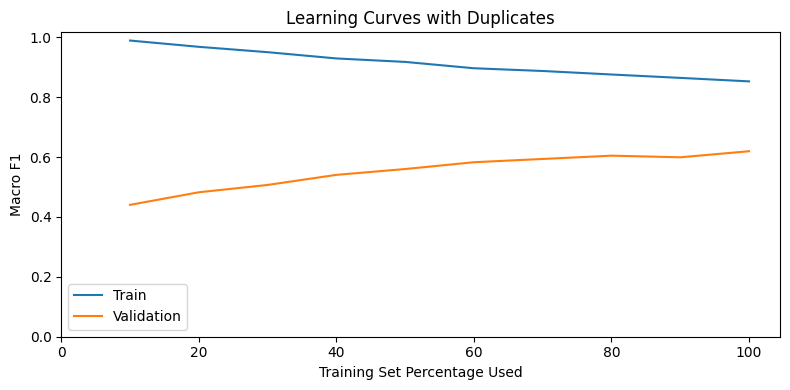

1/10 | Train F1: 0.99 | Val F1: 0.44 | size: 287
2/10 | Train F1: 0.97 | Val F1: 0.47 | size: 574
3/10 | Train F1: 0.95 | Val F1: 0.51 | size: 861
4/10 | Train F1: 0.93 | Val F1: 0.54 | size: 1148
5/10 | Train F1: 0.92 | Val F1: 0.56 | size: 1435
6/10 | Train F1: 0.90 | Val F1: 0.58 | size: 1722
7/10 | Train F1: 0.89 | Val F1: 0.60 | size: 2009
8/10 | Train F1: 0.88 | Val F1: 0.60 | size: 2296
9/10 | Train F1: 0.86 | Val F1: 0.60 | size: 2583
10/10 | Train F1: 0.85 | Val F1: 0.61 | size: 2870


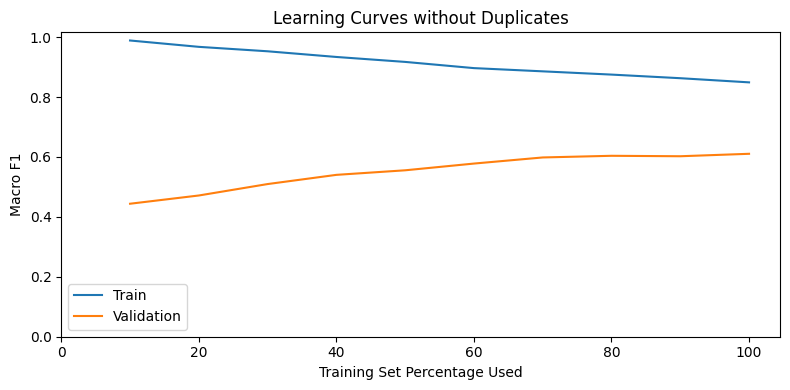

In [152]:
# Learning curves comparison: with vs without duplicates
plot_learning_curves(lr_dup, X_tr_dup, y_train, X_vl_dup, y_val, "Learning Curves with Duplicates")
plot_learning_curves(lr_dedup, X_tr_dedup, y_train_dedup, X_vl_dedup, y_val, "Learning Curves without Duplicates")

In [153]:
# Same comparison for embedding model
lr_dup_w2v = LogisticRegression(
    C=best_params_w2v_v2_cv["lr__C"], solver=best_params_w2v_v2_cv["lr__solver"],
    penalty=best_params_w2v_v2_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_dup_w2v.fit(X_train_w2v_v2, y_train)
f1_dup_w2v = f1_score(y_val, lr_dup_w2v.predict(X_val_w2v_v2), average="macro")

# Without duplicates
train_set_dedup = train_set.drop_duplicates(subset='input', keep='first').reset_index(drop=True)
X_train_w2v_dedup = np.array([average_embedding(t, best_emb_model) for t in train_set_dedup["input"]])
y_train_dedup = train_set_dedup["clarity_label"]

lr_dedup_w2v = LogisticRegression(
    C=best_params_w2v_v2_cv["lr__C"], solver=best_params_w2v_v2_cv["lr__solver"],
    penalty=best_params_w2v_v2_cv["lr__penalty"], max_iter=1000,
    random_state=SEED, class_weight="balanced"
)
lr_dedup_w2v.fit(X_train_w2v_dedup, y_train_dedup)
f1_dedup_w2v = f1_score(y_val, lr_dedup_w2v.predict(X_val_w2v_v2), average="macro")

print(f"{best_emb_name} v2 with duplicates (n={len(X_train_w2v_v2)}): Val F1: {f1_dup_w2v:.3f}")
print(f"{best_emb_name} v2 without duplicates (n={len(X_train_w2v_dedup)}): Val F1: {f1_dedup_w2v:.3f}")

GloVe v2 with duplicates (n=2930): Val F1: 0.494
GloVe v2 without duplicates (n=2870): Val F1: 0.503


In [154]:
# Deduplication effect on embedding model on test set
train_df_dedup = train_df.drop_duplicates(subset='input', keep='first').reset_index(drop=True)

X_full_w2v_dedup = np.array([average_embedding(t, best_emb_model) for t in train_df_dedup["input"]])
y_full_dedup = train_df_dedup["clarity_label"]

# No class_weight
lr_dedup_test = LogisticRegression(
    C=best_params_w2v_v2_cv["lr__C"], solver=best_params_w2v_v2_cv["lr__solver"],
    penalty=best_params_w2v_v2_cv["lr__penalty"], max_iter=1000,
    random_state=SEED
)
lr_dedup_test.fit(X_full_w2v_dedup, y_full_dedup)
y_pred_dedup_test = lr_dedup_test.predict(X_test_w2v_trial)

print(f"{best_emb_name} v2 no class_weight (with duplicates): Macro F1={macro_w2v_nb:.3f} | Weighted F1={weighted_w2v_nb:.3f}")
print(f"{best_emb_name} v2 no class_weight (without duplicates): Macro F1={f1_score(y_test, y_pred_dedup_test, average='macro'):.3f} | Weighted F1={f1_score(y_test, y_pred_dedup_test, average='weighted'):.3f}")

GloVe v2 no class_weight (with duplicates): Macro F1=0.399 | Weighted F1=0.590
GloVe v2 no class_weight (without duplicates): Macro F1=0.392 | Weighted F1=0.584


### Trying alternative Classifiers   

In [155]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC, SVC

classifiers = {
    "Random Forest": RandomForestClassifier(random_state=SEED, class_weight="balanced"),
    "SGD Classifier": SGDClassifier(random_state=SEED, class_weight="balanced"),
    "Ridge Classifier": RidgeClassifier(class_weight="balanced"),
    "Linear SVM": LinearSVC(random_state=SEED, class_weight="balanced"),
    # "SVM": SVC(random_state=SEED, class_weight="balanced") # kernel="rbf"
}

In [156]:
# Try on TF-IDF (v3 CV)
f1_lr = f1_score(y_val, y_pred_val_tfidf_v3, average="macro")
print("TF-IDF:")
print(f"Logistic Regression (v3): {f1_lr:.3f}")

for name, clf in classifiers.items():
  clf.fit(X_train_tfidf_v3, y_train)
  y_pred = clf.predict(X_val_tfidf_v3)
  f1 = f1_score(y_val, y_pred, average="macro")
  print(f"{name}: {f1:.3f}")

TF-IDF:
Logistic Regression (v3): 0.620
Random Forest: 0.542
SGD Classifier: 0.609
Ridge Classifier: 0.618
Linear SVM: 0.623


In [157]:
# Try on best performing embedding model
f1_lr_w2v = f1_score(y_val, y_pred_val_w2v_v1, average="macro")
print("Best Embedding Representation:")
print(f"Logistic Regression (v1): {f1_lr_w2v:.3f}")

for name, clf in classifiers.items():
  clf.fit(X_train_w2v_v2, y_train)
  y_pred = clf.predict(X_val_w2v_v2)
  f1 = f1_score(y_val, y_pred, average="macro")
  print(f"{name}: {f1:.3f}")

Best Embedding Representation:
Logistic Regression (v1): 0.467
Random Forest: 0.425
SGD Classifier: 0.338
Ridge Classifier: 0.474
Linear SVM: 0.496


## Download all Figures

In [158]:
# Download all generated images
import zipfile
import os
from google.colab import files

with zipfile.ZipFile("figures.zip", "w") as zipf:
  for f in os.listdir("."):
    if f.endswith(".png"):
      zipf.write(f)

files.download("figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>